In [3]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34975,Workers: 56
Dashboard: http://127.0.0.1:8787/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:46467,Total threads: 1
Dashboard: http://127.0.0.1:35473/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:44279,


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from string import ascii_lowercase, ascii_uppercase
import seaborn as sns
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from cmap import Colormap
import seaborn as sns

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
xr.__version__

'2026.4.0'

In [4]:
xr.set_options(keep_attrs=True)
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
plt.rcParams.update({"font.size": 18})

In [5]:
def anomalize(ds):
    clim = ds.groupby('time.month').mean('time')
    ds_anom = (ds.groupby('time.month')-clim).groupby('time.month')
    std = ds.groupby('time.month').std('time')
    return ds_anom/std, clim, std

def process(ds, sel_var, deseasonalize=True):
    #ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="ME", periods=ds.time.shape[0])
   

    ds = ds[[sel_var]].sel(time = slice('2022-01',None))/100.
    ds[sel_var].attrs['units'] = 'hPa'


    if deseasonalize:
        ds, _, _= anomalize(ds)  # deseasonalize_func(ds)

    return ds.squeeze()

lf = lambda x: x.stem.split('_')[1][4:]

def process_chem(ds, deseasonalize=True, upper_limit=0.1, lower_limit=300):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds.sel(plev=slice(upper_limit, lower_limit))

def soi_index(ds):
    tahiti_lat, tahiti_lon = -17.65, 210.55
    darwin_lat, darwin_lon = -12.46, 130.84
    Darwin_dict = dict(lon = darwin_lon,lat = darwin_lat, method = 'nearest')
    Tahiti_dict = dict(lon = tahiti_lon,lat = tahiti_lat, method='nearest')
    arr1 = ds['psl'].sel(**Tahiti_dict).load()
    arr2 = ds['psl'].sel(**Darwin_dict).load()
    soi_index = arr1-arr2
    soi_index_g = soi_index.groupby('time.month')
    m = soi_index_g.mean('time')
    s = soi_index_g.std('time')
    soi_index = 10*((soi_index_g-m).groupby('time.month')/s)
    #std = soi_index.where(~mask).std('time')
    #print(std.values)
    return arr1, arr2, soi_index.rolling(time = 3, center=True).mean()

def composite_year(arr, sel_dict, mean_bool=False):
    sel_arr = arr.sel(**sel_dict)
    if mean_bool:
        sel_arr = sel_arr.mean('time')
    return sel_arr

In [1]:
210.55-360

-149.45

In [2]:
130.84-360

-229.16

In [6]:
what = "chem_mm_zon"
infiles_w = sorted(infile_path.glob(f"socol4_htt1?_{what}*"))
infiles_wo = sorted(infile_path.glob(f"socol4_htt2?_{what}*"))

In [8]:
ds_wo_chem = (
    xr.open_mfdataset(
        infiles_wo,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_wo_chem['ens'] = list(map(lf, infiles_wo))

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tmp/ipykernel_4115474/39914528.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  xr.open_mfdataset(
/tmp/ipykernel_4115474/979616158.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01"

In [9]:
ds_w_chem = (
    xr.open_mfdataset(
        infiles_w,
        parallel=True,  #  will be performed in parallel using dask.delayed
        combine="nested",
        concat_dim=["ens"],
    )
    .pipe(process_chem, deseasonalize=False, upper_limit=0.01, lower_limit = 120)
    .load()
)
ds_w_chem['ens'] = list(map(lf, infiles_w))

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tmp/ipykernel_4115474/979616158.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ds["time"] = pd.date_range("2021-01", freq="M", periods=ds.time.shape[0])


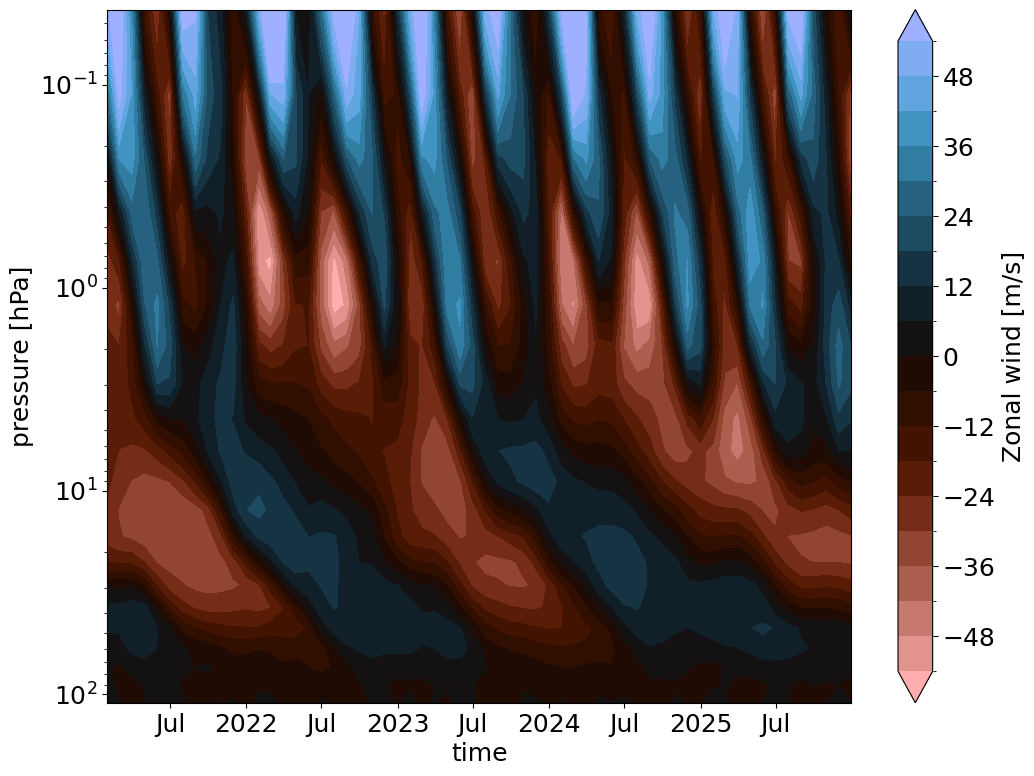

In [394]:
ds_w_chem['u_m'].sel(lat = 0, method ='nearest').mean('ens').squeeze().plot.contourf(x = 'time', yincrease = False, levels = 21, robust = True, size = 9, cmap = 'berlin_r')
plt.yscale('log')
plt.title('')
plt.savefig('QBO_SOCOL.pdf', bbox_inches='tight')

In [10]:
pv_w = ds_w_chem['u_m'].sel(lat = 60, plev = 10, method ='nearest').squeeze()
pv_wo = ds_wo_chem['u_m'].sel(lat = 60, plev = 10, method ='nearest').squeeze()
#diff_pv = pv_w.mean('ens')-pv_wo.mean('ens')
diff_pv = pv_w-pv_wo
diff_pv.name = 'u6010'

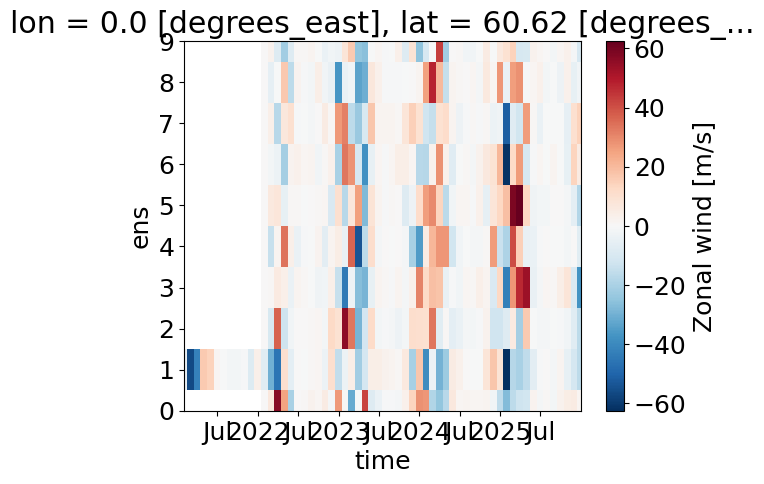

In [17]:
diff_pv.plot()

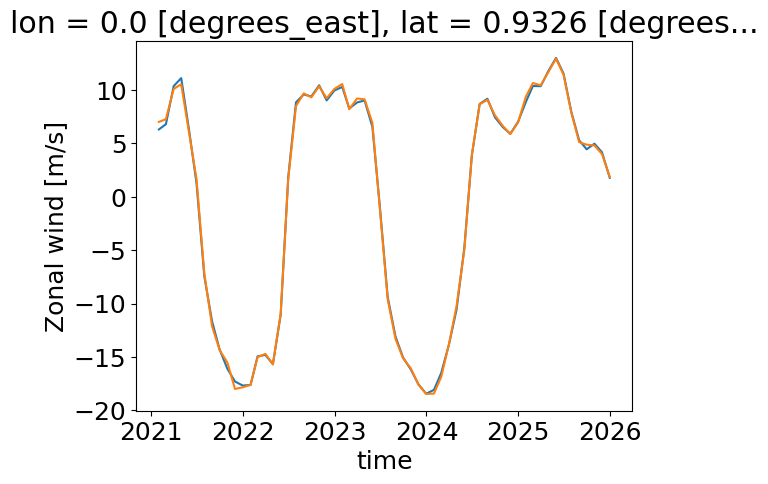

In [774]:
qboi_w = ds_w_chem['u_m'].sel(lat = 0, plev = 50, method ='nearest') # instead of 50 hPa as in obs
qboi_wo = ds_wo_chem['u_m'].sel(lat = 0, plev = 50, method ='nearest')

qboi_w.mean('ens').plot()
qboi_wo.mean('ens').plot()

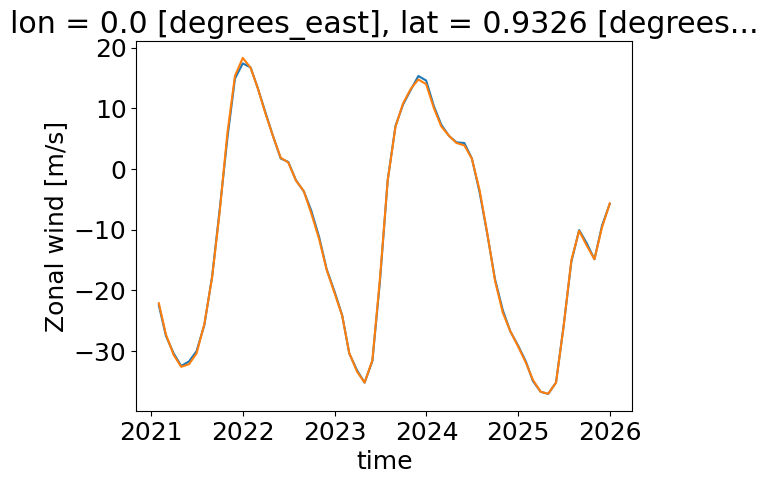

In [11]:
qboi_w = ds_w_chem['u_m'].sel(lat = 0, plev = 10, method ='nearest') # instead of 50 hPa as in obs
qboi_wo = ds_wo_chem['u_m'].sel(lat = 0, plev = 10, method ='nearest')

qboi_w.mean('ens').plot()
qboi_wo.mean('ens').plot()

In [471]:
ds_w_chem['u_m'].sel(
    lat = 0,
    time = '2022-01-15', method ='nearest',
    plev = 25,
)

<xarray.DataArray 'u_m' (ens: 10, lon: 1)> Size: 40B
array([[-15.870991],
       [-16.874336],
       [-15.696074],
       [-15.855812],
       [-16.71117 ],
       [-15.493636],
       [-17.24513 ],
       [-16.024485],
       [-16.332777],
       [-16.788284]], dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2021-12-31
  * lon      (lon) float64 8B 0.0
    lat      float64 8B 0.9326
    plev     float64 8B 22.35
  * ens      (ens) <U5 200B 'htt10' 'htt11' 'htt12' ... 'htt17' 'htt18' 'htt19'
Attributes:
    long_name:         Zonal wind
    units:             m/s
    code:              10
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

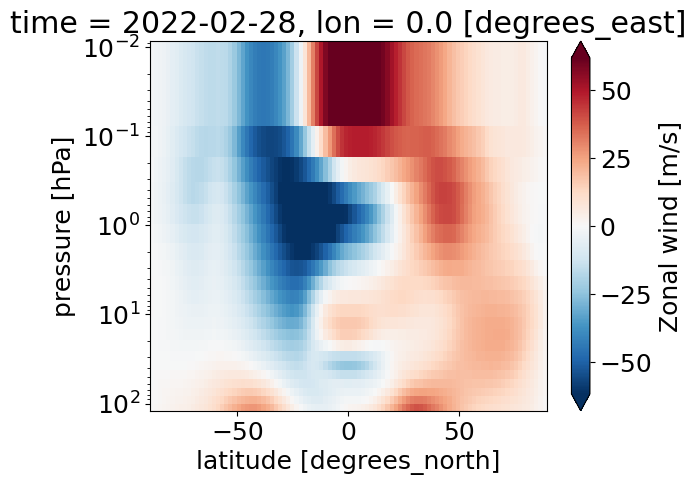

In [467]:
ds_w_chem['u_m'].sel(
    time = '2022-02-15', method ='nearest'
).sel(lat = slice(None,None)).mean('ens').plot(yincrease = False, robust = True)
plt.yscale('log')

In [11]:
what = "slp_mm"
infiles_w = sorted(infile_path.glob(f"socol4_htt1*{what}*2025.nc"))
infiles_wo = sorted(infile_path.glob(f"socol4_htt2*{what}*2025.nc"))
infiles_w

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt10_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt11_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt12_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt13_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt14_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt15_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt16_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt17_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt18_slp_mm_2021-2025.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt19_slp_mm_2021-2025.nc')]

In [12]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, 'psl', deseasonalize=False)
ds_w['ens'] = list(map(lf, infiles_w))
ds_w

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 48, lon: 192, lat: 96, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 384B 2022-01-31 2022-02-28 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
Data variables:
    psl      (ens, time, lat, lon) float32 35MB dask.array<chunksize=(1, 48, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    history:      Thu May 09 21:43:44 2024: cdo cat Postproc_example-slp-para...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [13]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    #chunks = {'plev':1},
    concat_dim=["ens"],
    #data_vars='minimal', coords='minimal', compat='override'
).pipe(process, 'psl', deseasonalize=False)
ds_wo['ens'] = list(map(lf, infiles_wo))
ds_wo

<xarray.Dataset> Size: 35MB
Dimensions:  (time: 48, lon: 192, lat: 96, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 384B 2022-01-31 2022-02-28 ... 2025-12-31
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
Data variables:
    psl      (ens, time, lat, lon) float32 35MB dask.array<chunksize=(1, 48, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    frequency:    mon
    history:      Thu May 09 21:43:49 2024: cdo cat Postproc_example-slp-para...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

(array([   5338.,   90897.,  374836.,  621661.,  684519., 1492331.,
        3763416., 1639360.,  168821.,    6181.]),
 array([ 959.83843994,  968.12756348,  976.41674805,  984.70593262,
         992.99505615, 1001.28417969, 1009.57336426, 1017.86254883,
        1026.15161133, 1034.4407959 , 1042.72998047]),
 <BarContainer object of 10 artists>)

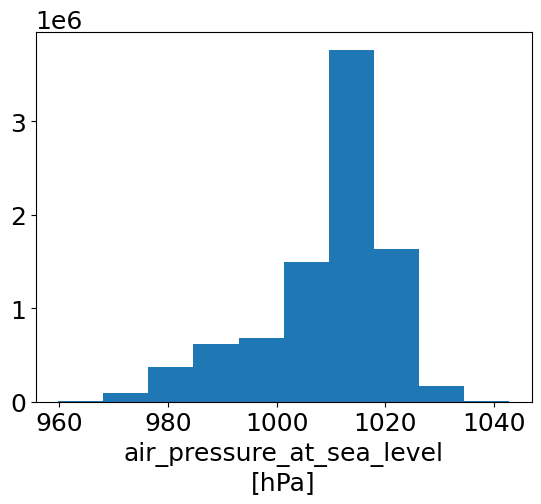

In [303]:
ds_wo['psl'].plot.hist()

In [15]:
arr1, arr2, soi_wo = soi_index(ds_wo)
arr1, arr2, soi_w = soi_index(ds_w)

In [12]:
soi_w.to_netcdf('soi_w.nc')
soi_wo.to_netcdf('soi_wo.nc')

NameError: name 'soi_w' is not defined

In [13]:
soi_w = xr.open_dataset('soi_w.nc')
soi_wo = xr.open_dataset('soi_wo.nc')

In [9]:
soi_wo

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 48, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 384B 2022-01-31 2022-02-28 ... 2025-12-31
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
    month    (time) int64 384B ...
Data variables:
    psl      (ens, time) float32 2kB ...

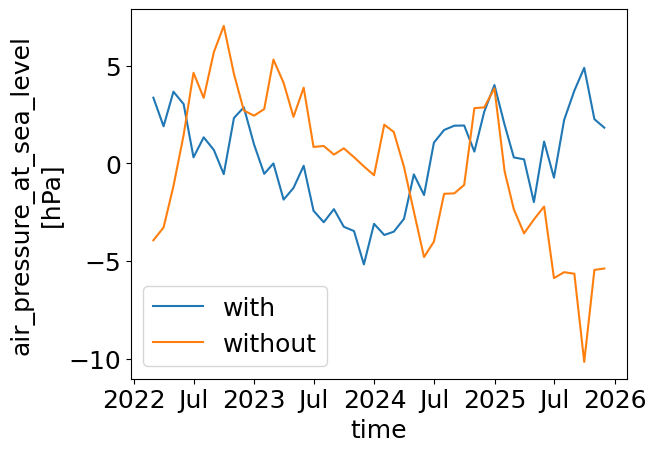

In [753]:
soi_w.median('ens').plot(label = 'with')
soi_wo.median('ens').plot(label = 'without')
plt.legend()

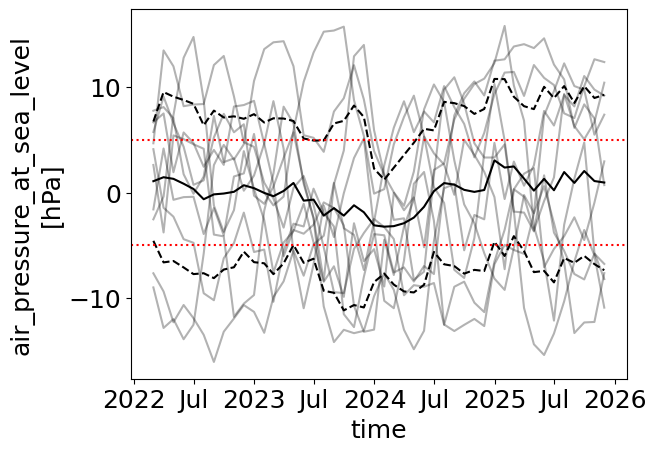

In [662]:
soi_w.plot(hue = 'ens', c = 'k', add_legend = False, alpha = 0.3)
m = soi_w.mean('ens')
m.plot(c = 'k')
s = soi_w.std('ens')
upper = m+s
upper.plot(c = 'k', ls = 'dashed')
upper = m-s
upper.plot(c = 'k', ls = 'dashed')
plt.axhline(5, c = 'r', ls = 'dotted')
plt.axhline(-5, c = 'r', ls = 'dotted')

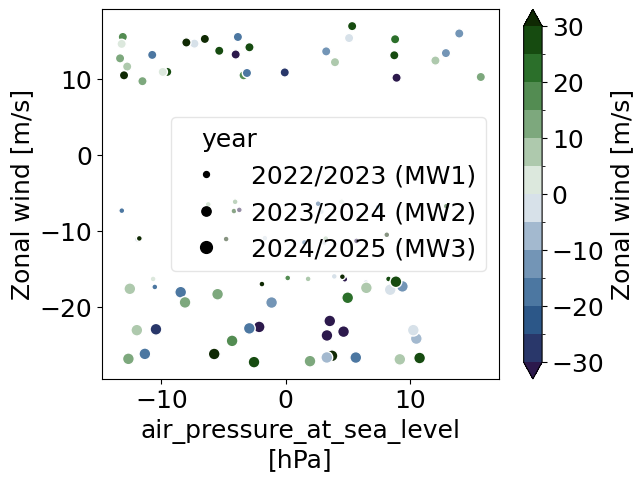

In [100]:
temp_ls = []
year_ls = range(2022, 2025)
for year in year_ls:
    sel_dict = dict(time = slice(f'{year}-09',f'{year}-11'))
    temp_soi = composite_year(soi_w, sel_dict)
    temp_qbo = composite_year(qboi_w.squeeze().reset_coords(drop=True), sel_dict)

    sel_dict = dict(time = slice(f'{year}-12',f'{year+1}-02'))
    temp_pv =  composite_year(diff_pv.reset_coords(drop=True), sel_dict)
    temp_pv['time'] = temp_soi['time'].values
    temp_ls.append(xr.merge([temp_soi, temp_qbo, temp_pv]))

temp_all = xr.concat(temp_ls, dim = 'year')
year_ls_lambda = list(map(lambda x,y: str(x)+'/'+str(x+1) + f' (MW{y+1})', year_ls, range(len(year_ls))))
temp_all['year'] = year_ls_lambda
cm = Colormap('cork')  #'crameri:vik')
cmap = cm.to_matplotlib()
temp_all.plot.scatter(
    x = 'psl', y = 'u_m', hue = 'u6010', 
    #hue_style="discrete",
    linewidth = 200,
    levels = np.arange(-30,35,5),
    cmap = cmap, markersize = 'year')

In [101]:
df = temp_all.mean('time').to_dataframe().reset_index()
df = df.rename(columns = {'u6010': 'ZW@60N,10hPa'})
df

,year,ens,psl,u_m,"ZW@60N,10hPa"
0,2022/2023 (MW1),0,8.943978,-11.587490,-1.187749
1,2022/2023 (MW1),1,-11.938994,-11.631965,-4.948441
2,2022/2023 (MW1),2,-4.311234,-11.565678,32.937344
3,2022/2023 (MW1),3,6.546192,-11.711940,-20.768749
4,2022/2023 (MW1),4,4.070969,-11.288791,12.171636
5,2022/2023 (MW1),5,-0.245643,-11.375845,0.055206
6,2022/2023 (MW1),6,6.354903,-11.126167,13.779251
7,2022/2023 (MW1),7,-8.828798,-11.957689,13.915124
8,2022/2023 (MW1),8,-0.493806,-11.432658,-14.396853
9,2022/2023 (MW1),9,2.095569,-11.594799,7.036447


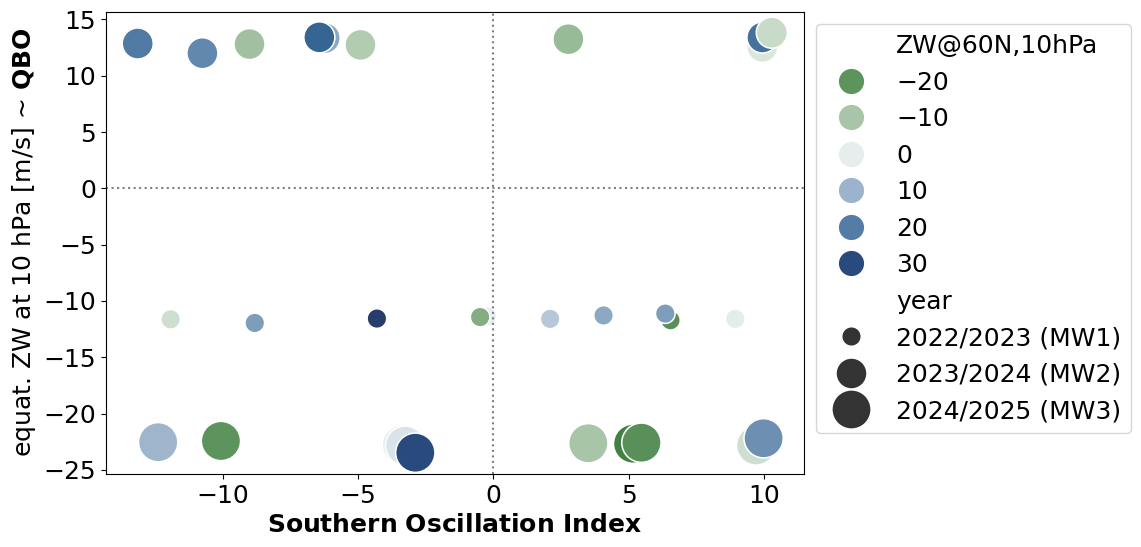

In [102]:
plt.rcParams['lines.markersize'] = 19.25
cm = Colormap('cork_r')  #'crameri:vik')
cmap = cm.to_matplotlib()
fig = plt.figure(figsize=(9,6))
ax = sns.scatterplot(
    data = df,   x = 'psl', y = 'u_m', 
    hue = 'ZW@60N,10hPa',  palette= cmap, 
    size ='year', hue_norm=(-40, 40),
    sizes=(800, 200)    
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.axhline(0, ls = 'dotted', c = 'gray')
ax.axvline(0, ls = 'dotted', c = 'gray')
ax.set_xlabel(r'$\mathbf{Southern~Oscillation~Index}$')
ax.set_ylabel(r'equat. ZW at 10 hPa [m/s] ~ $\mathbf{QBO}$')
outfile = 'QBO@10hPa_vs_SOI_SOCOLw-only_colored_seaborn.pdf'
plt.savefig(outfile,  bbox_inches='tight')

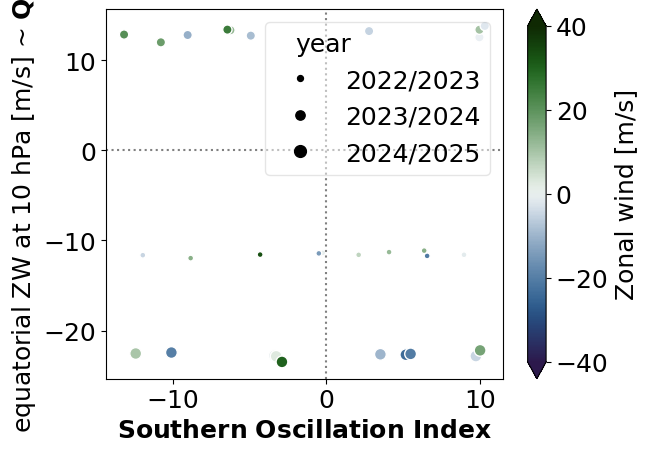

In [41]:
plt.rcParams['lines.markersize'] = 1000.25

vmax = 40
p = temp_all.mean('time').plot.scatter(
    x = 'psl', y = 'u_m', hue = 'u6010', 
    markersize = 'year',
    cmap = cmap, vmin = -vmax, vmax = vmax, extend = 'both', 
    **dict(s=40000),
    hue_style="discrete",
)
ax = p.axes
ax.axhline(0, ls = 'dotted', c = 'gray')
ax.axvline(0, ls = 'dotted', c = 'gray')
ax.set_xlabel(r'$\mathbf{Southern~Oscillation~Index}$')
ax.set_ylabel(r'equatorial ZW at 10 hPa [m/s] ~ $\mathbf{QBO}$')
outfile = 'QBO@10hPa_vs_SOI_SOCOLw-only_colored.pdf'
#plt.savefig(outfile,  bbox_inches='tight')

In [103]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [104]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

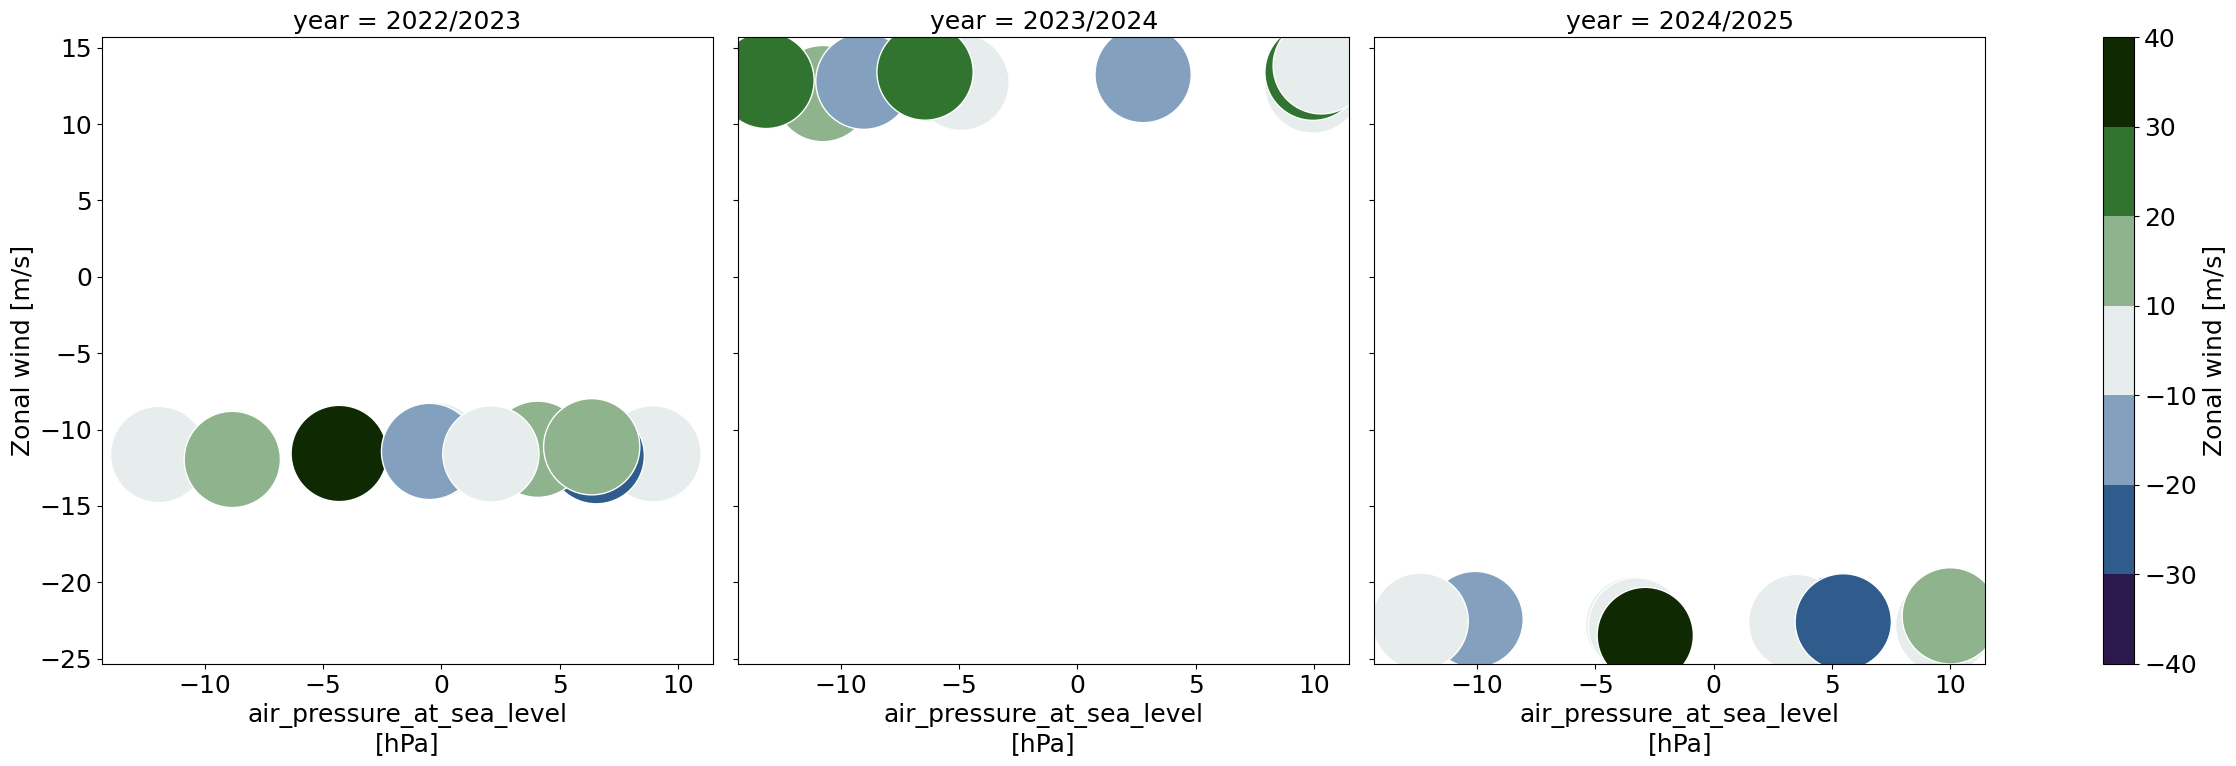

In [40]:
temp_all.mean('time').plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', cmap = cmap, col = 'year', levels = [-40,-30,-20,-10,10,20,30,40], size = 8, **dict(s=4800))

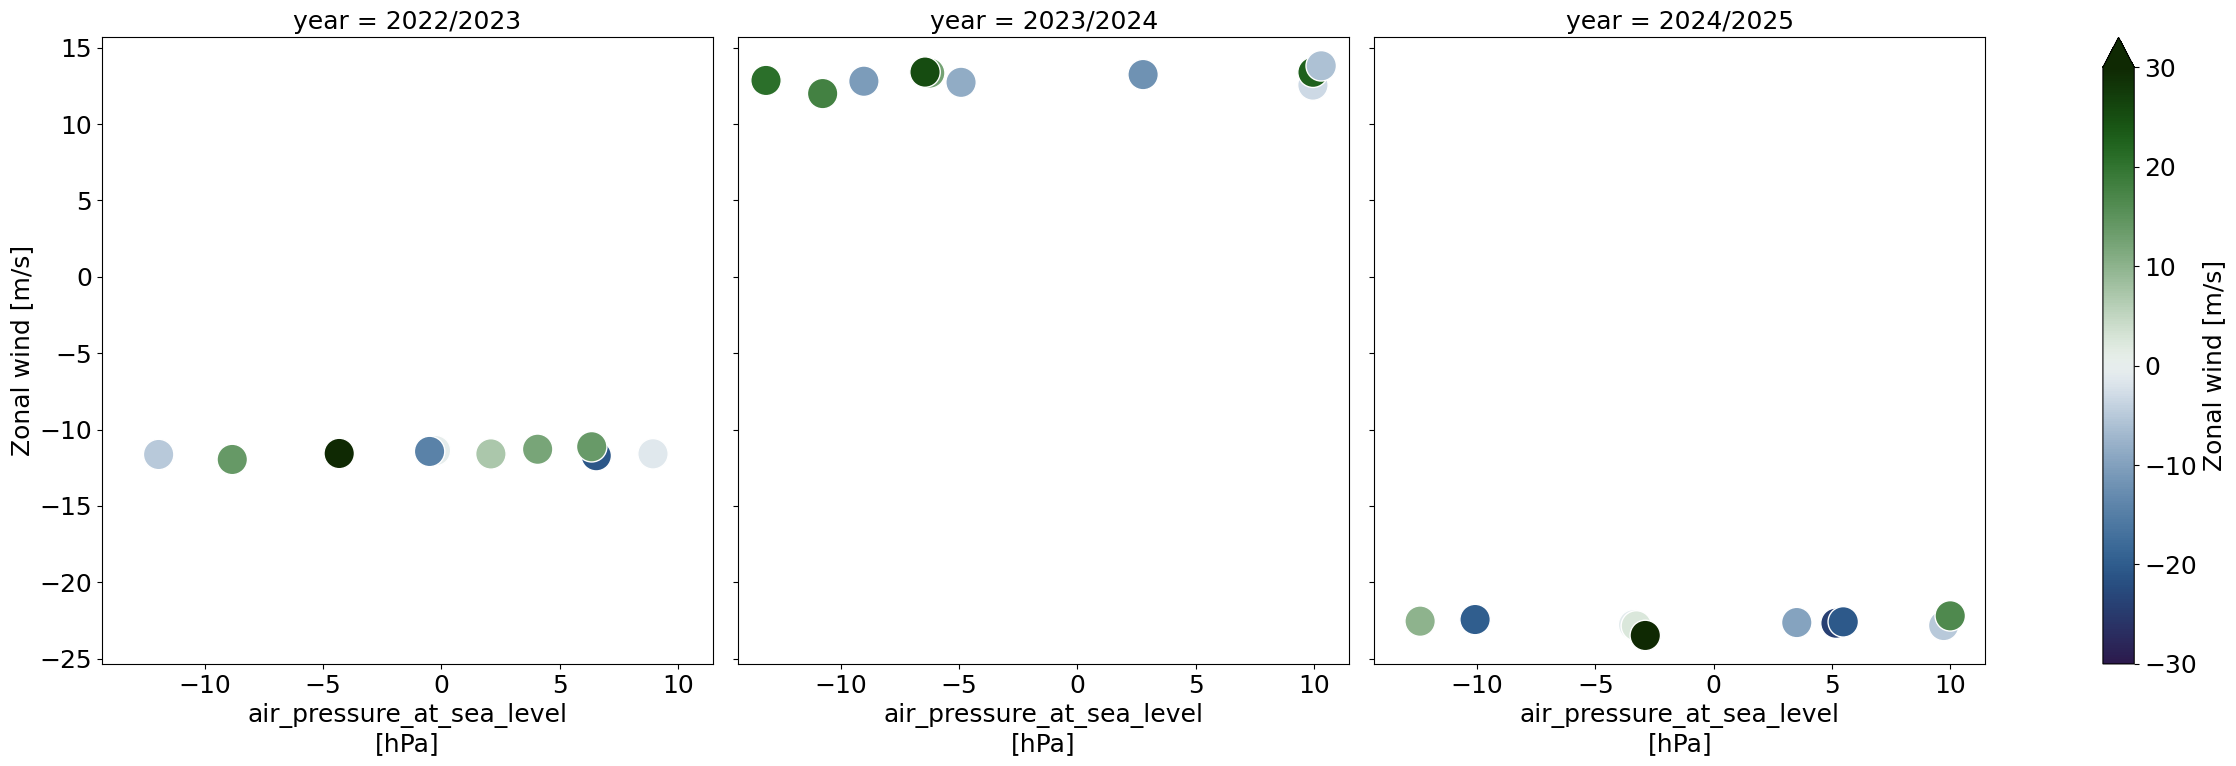

In [693]:
temp_all.mean('time').plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', cmap = cmap, col = 'year', vmin = -30, vmax = 30, size = 8, **dict(s=480))

In [769]:
temp_all

<xarray.Dataset> Size: 4kB
Dimensions:  (year: 3, ens: 10, time: 9)
Coordinates:
  * time     (time) datetime64[ns] 72B 2022-09-30 2022-10-31 ... 2024-11-30
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
    month    (year, time) float64 216B 9.0 10.0 11.0 nan ... nan 9.0 10.0 11.0
  * year     (year) <U9 108B '2022/2023' '2023/2024' '2024/2025'
Data variables:
    psl      (year, ens, time) float32 1kB 12.95 9.116 4.769 ... -11.99 -12.67
    u_m      (year, ens, time) float32 1kB -6.787 -11.57 -16.4 ... -23.1 -26.88
    u6010    (year, ens, time) float32 1kB 27.27 0.489 -31.32 ... 9.488 14.5
Attributes:
    standard_name:     air_pressure_at_sea_level
    units:             hPa
    code:              151
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    cell_methods:      time: mean

In [739]:
#df_to_pivot = temp_all.mean('time').to_dataframe().reset_index()
df_to_pivot = temp_all.to_dataframe().reset_index()
df_to_pivot['QBO'] = pd.cut(df_to_pivot['u_m'], [-30,-1,1,30])
#df_to_pivot['SOI'] = pd.cut(df_to_pivot['psl'], np.arange(-10,12,2))
df_to_pivot['SOI'] = pd.cut(df_to_pivot['psl'], [-10,-4,4,10])
df_to_pivot

,year,ens,time,psl,u_m,u6010,month,QBO,SOI
0,2022/2023,0,2022-09-30,12.946792,-6.787103,27.269794,9.0,"(-30.0, -1.0]",NaN
1,2022/2023,0,2022-10-31,9.116234,-11.573485,0.488968,10.0,"(-30.0, -1.0]","(4.0, 10.0]"
2,2022/2023,0,2022-11-30,4.768909,-16.401880,-31.322008,11.0,"(-30.0, -1.0]","(4.0, 10.0]"
3,2022/2023,0,2023-09-30,NaN,NaN,NaN,NaN,NaN,NaN
4,2022/2023,0,2023-10-31,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
265,2024/2025,9,2023-10-31,NaN,NaN,NaN,NaN,NaN,NaN
266,2024/2025,9,2023-11-30,NaN,NaN,NaN,NaN,NaN,NaN
267,2024/2025,9,2024-09-30,-12.550742,-17.657915,5.928192,9.0,"(-30.0, -1.0]",NaN
268,2024/2025,9,2024-10-31,-11.986518,-23.104170,9.488455,10.0,"(-30.0, -1.0]",NaN


In [ ]:
df['ENSO'] = ['neutral']*df.shape[0]
df.loc[df['psl']>4,'ENSO'] = 'La Niña'
df.loc[df['psl']<-4,'ENSO'] = 'El Niño'

[Text(0.5, 0, 'El Niño'), Text(1.5, 0, 'Neutral'), Text(2.5, 0, 'La Niña')]

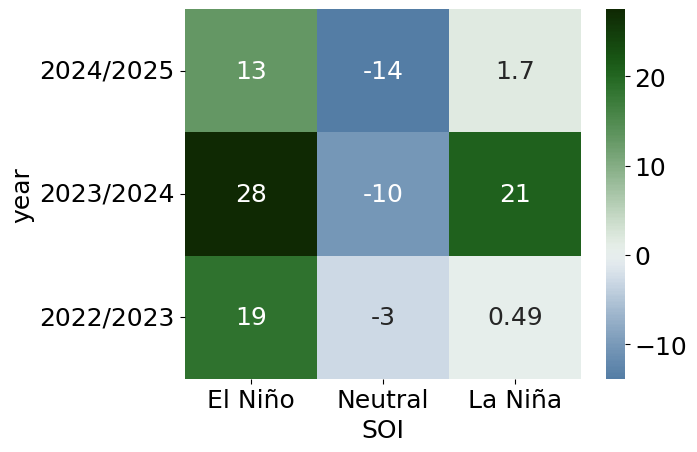

In [773]:
df_pivot = pd.pivot_table(df_to_pivot, columns="SOI", index="year", values = 'u6010', aggfunc= 'median')
df_pivot = df_pivot.sort_index(level=0, ascending=False,)
ax = sns.heatmap(df_pivot, center=0, cmap=cmap,  annot=True)
ax.set_xticklabels(['El Niño', 'Neutral', 'La Niña'])

In [771]:
p

<Axes: xlabel='SOI', ylabel='year'>

<Axes: xlabel='SOI', ylabel='QBO'>

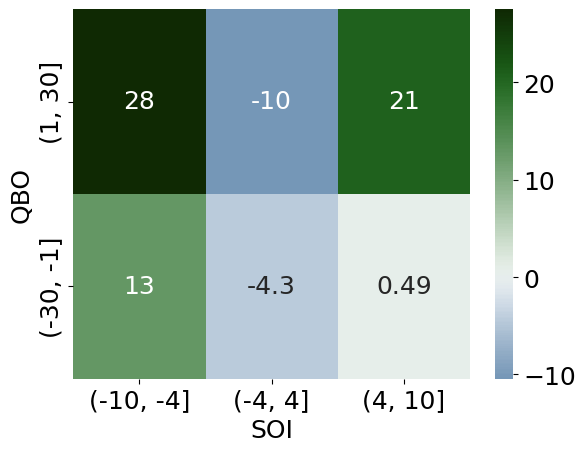

In [751]:
df_pivot = pd.pivot_table(df_to_pivot, columns="SOI", index="QBO", values = 'u6010', aggfunc= 'median')
df_pivot = df_pivot.sort_index(level=0, ascending=False,)
sns.heatmap(df_pivot, center=0, cmap=cmap,  annot=True)

<Axes: xlabel='SOI', ylabel='QBO'>

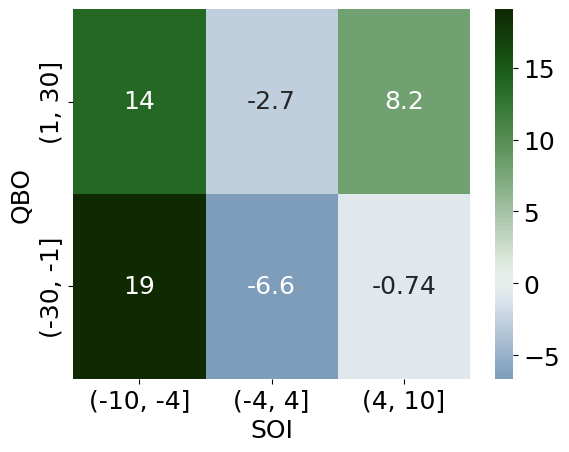

In [752]:
df_pivot = pd.pivot_table(df_to_pivot, columns="SOI", index="QBO", values = 'u6010', aggfunc= 'mean')
df_pivot = df_pivot.sort_index(level=0, ascending=False,)
sns.heatmap(df_pivot, center=0, cmap=cmap,  annot=True)

In [736]:
(14-2.7+8.2)/3

6.5

In [737]:
(19-6.6+-0.74)/3

3.8866666666666667

In [749]:
df = temp_all.to_dataframe().reset_index()
df['QBO'] = ['west']*df.shape[0]
df.loc[df['u_m']<-1,'QBO'] = 'east'
df['ENSO'] = ['neutral']*df.shape[0]
df.loc[df['psl']>4,'ENSO'] = 'La Niña'
df.loc[df['psl']<-4,'ENSO'] = 'El Niño'
df

,year,ens,time,psl,u_m,u6010,month,QBO,ENSO
0,2022/2023,0,2022-09-30,12.946792,-6.787103,27.269794,9.0,east,La Niña
1,2022/2023,0,2022-10-31,9.116234,-11.573485,0.488968,10.0,east,La Niña
2,2022/2023,0,2022-11-30,4.768909,-16.401880,-31.322008,11.0,east,La Niña
3,2022/2023,0,2023-09-30,NaN,NaN,NaN,NaN,west,neutral
4,2022/2023,0,2023-10-31,NaN,NaN,NaN,NaN,west,neutral
...,...,...,...,...,...,...,...,...,...
265,2024/2025,9,2023-10-31,NaN,NaN,NaN,NaN,west,neutral
266,2024/2025,9,2023-11-30,NaN,NaN,NaN,NaN,west,neutral
267,2024/2025,9,2024-09-30,-12.550742,-17.657915,5.928192,9.0,east,El Niño
268,2024/2025,9,2024-10-31,-11.986518,-23.104170,9.488455,10.0,east,El Niño


<Axes: xlabel='ENSO', ylabel='u6010'>

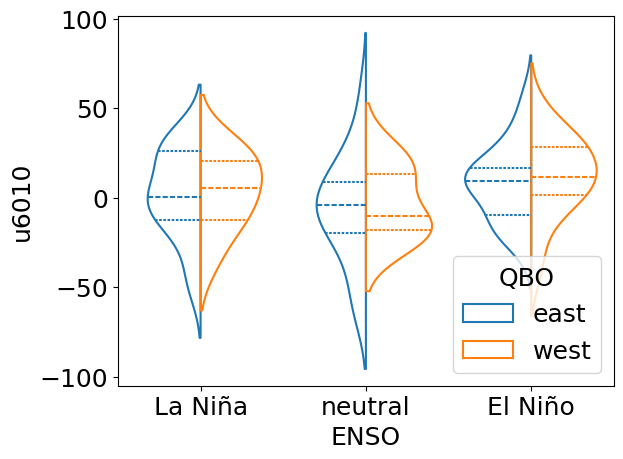

In [750]:
sns.violinplot(
    data=df, x="ENSO", y="u6010", hue="QBO",
    split=True, inner="quart", fill=False,
) # palette={"Yes": "g", "No": ".35"}

<Axes: xlabel='ENSO', ylabel='u6010'>

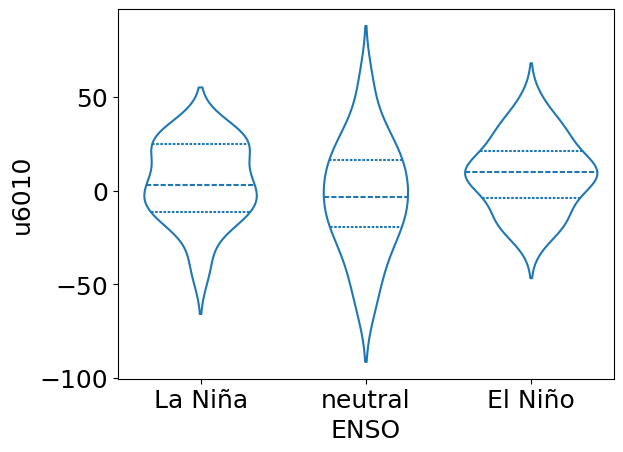

In [747]:
sns.violinplot(
    data=df, x="ENSO", y="u6010", inner="quart", fill=False,
) # palette={"Yes": "g", "No": ".35"}

<Axes: xlabel='QBO', ylabel='u6010'>

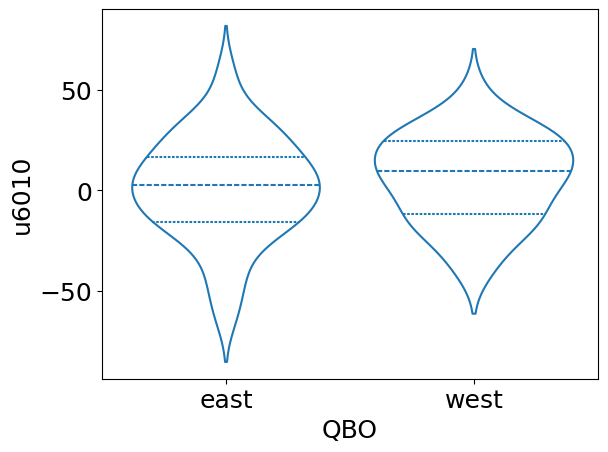

In [748]:
sns.violinplot(
    data=df, x="QBO", y="u6010", inner="quart", fill=False,
) # palette={"Yes": "g", "No": ".35"}

<xarray.DataArray 'u6010' ()> Size: 8B
array(9.76080799)
Attributes:
    long_name:         Zonal wind
    units:             m/s
    code:              10
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET
<xarray.DataArray 'u6010' ()> Size: 8B
array(2.42460442)
Attributes:
    long_name:         Zonal wind
    units:             m/s
    code:              10
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET


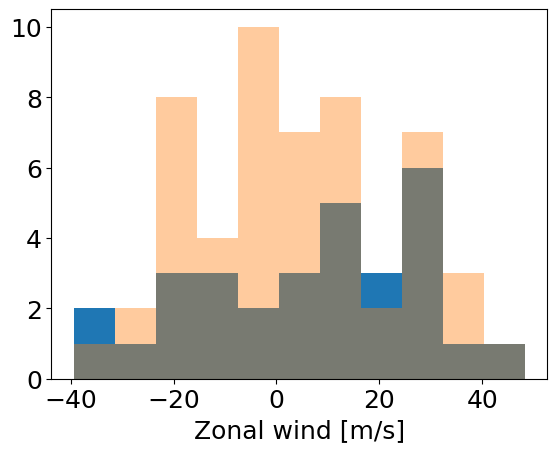

In [627]:
mask = (temp_all['u_m'] > 0)
temp = temp_all['u6010'].where(mask)
bins = temp.plot.hist(bins = 11)
print(temp.median())
temp = temp_all['u6010'].where(~mask)
temp.plot.hist(bins = bins[1], alpha = 0.4)
print(temp.median())

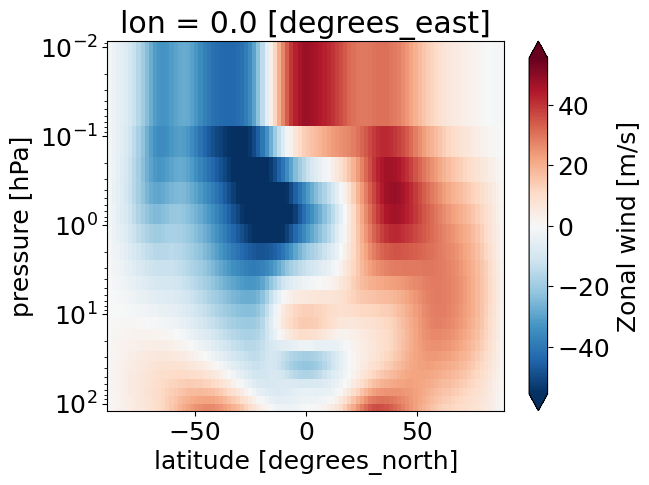

In [674]:
temp = ds_w_chem['u_m'].mean('ens').squeeze().where(qboi_w.mean('ens').squeeze() > 1)
mask = np.isin(temp.time.dt.month, [12,1,2])
p = temp.sel(time = mask).mean('time').plot(x = 'lat', yincrease = False, robust = True, extend = 'both')
plt.yscale('log')

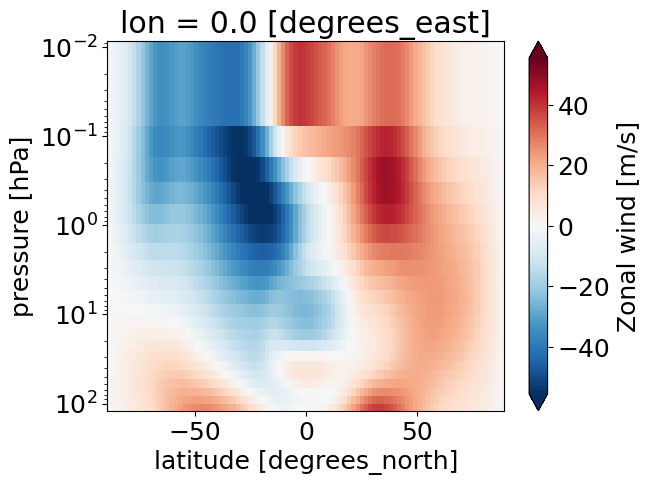

In [675]:
temp2 = ds_w_chem['u_m'].mean('ens').squeeze().where(qboi_w.mean('ens').squeeze() < -1)
mask = np.isin(temp2.time.dt.month, [12,1,2])
temp2.sel(time = mask).mean('time').plot(x = 'lat', yincrease = False, vmax = p.colorbar.vmax,  extend = 'both')
plt.yscale('log')

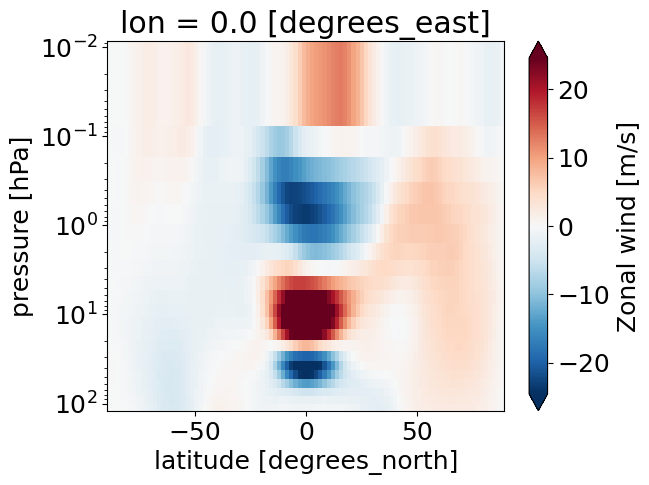

In [676]:
diff = temp.sel(time = mask).mean('time')-temp2.sel(time = mask).mean('time')
diff.plot(x = 'lat', yincrease = False, robust = True)
plt.yscale('log')

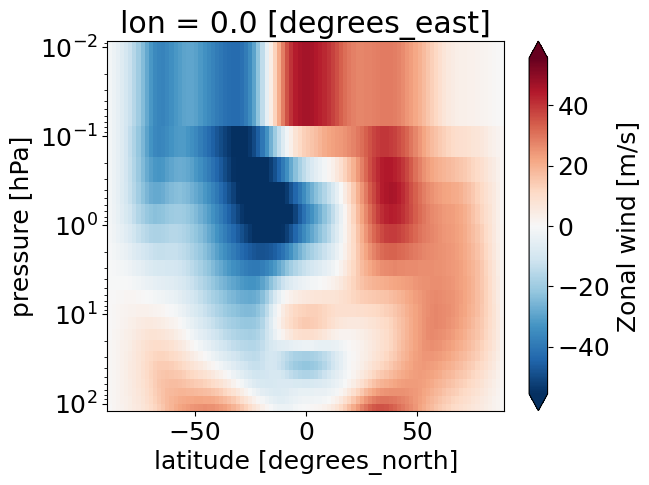

In [671]:
temp = ds_wo_chem['u_m'].mean('ens').squeeze().where(qboi_wo.mean('ens').squeeze() > 1)
mask = np.isin(temp.time.dt.month, [12,1,2])
p = temp.sel(time = mask).mean('time').plot(x = 'lat', yincrease = False, robust = True, extend = 'both')
plt.yscale('log')

In [670]:
qboi_w.mean('ens').squeeze() < -1 

<xarray.DataArray 'u_m' (time: 60)> Size: 60B
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
    lon      float64 8B 0.0
    lat      float64 8B 0.9326
    plev     float64 8B 9.011
Attributes:
    long_name:         Zonal wind
    units:             m/s
    code:              10
    table:             199
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    institution:       MPIMET

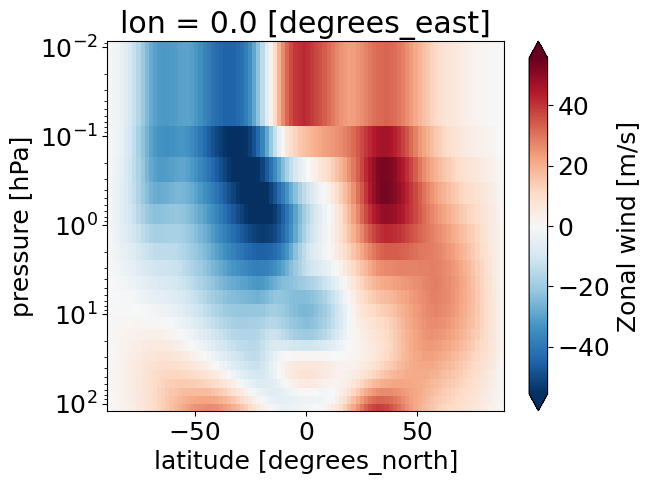

In [672]:
temp2 = ds_wo_chem['u_m'].mean('ens').squeeze().where(qboi_wo.mean('ens').squeeze() < -1)
mask = np.isin(temp2.time.dt.month, [12,1,2])
temp2.sel(time = mask).mean('time').plot(x = 'lat', yincrease = False, vmax = p.colorbar.vmax,  extend = 'both')
plt.yscale('log')

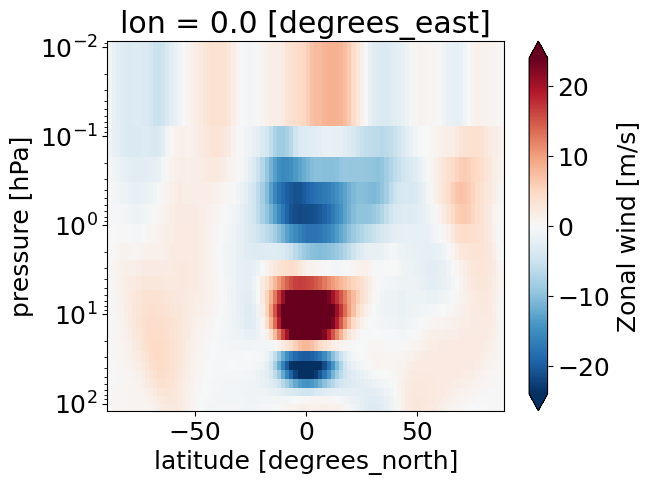

In [673]:
diff = temp.sel(time = mask).mean('time')-temp2.sel(time = mask).mean('time')
diff.plot(x = 'lat', yincrease = False, robust = True)
plt.yscale('log')

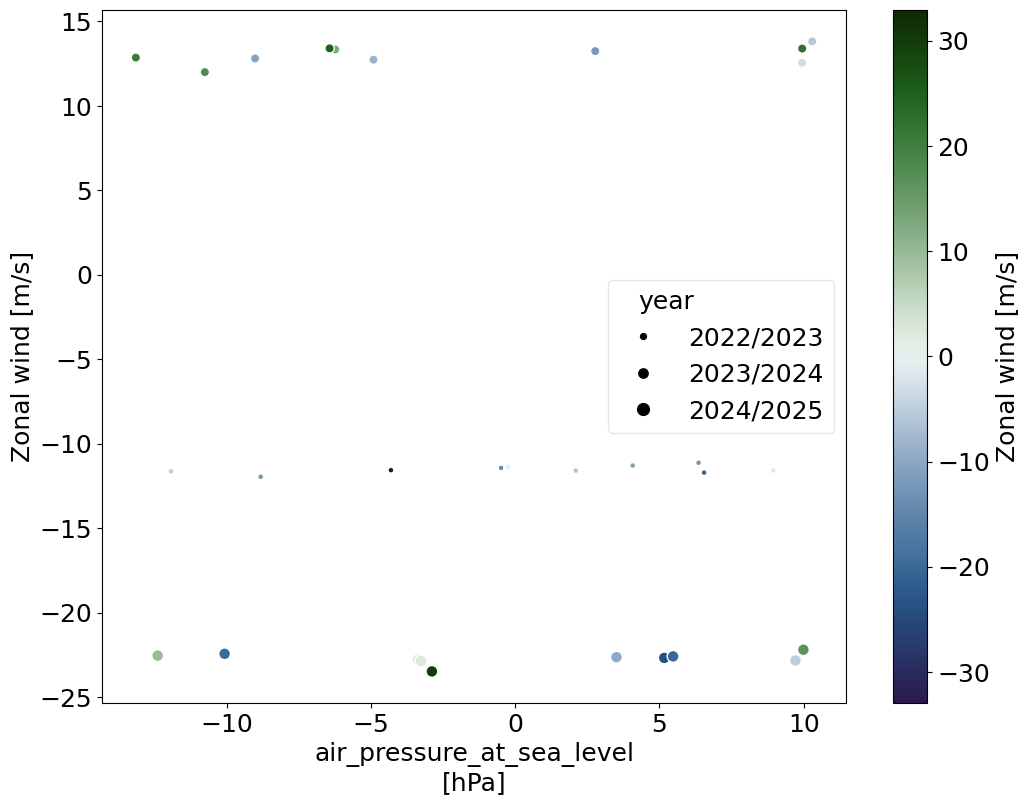

In [628]:
temp_ls = []
year_ls = range(2022, 2025)
for year in year_ls:
    sel_dict = dict(time = slice(f'{year}-09',f'{year}-11'))
    temp_soi = composite_year(soi_w, sel_dict, mean_bool=True)
    temp_qbo = composite_year(qboi_w.squeeze().reset_coords(drop=True), sel_dict, mean_bool=True)

    sel_dict = dict(time = slice(f'{year}-12',f'{year+1}-02'))
    temp_pv =  composite_year(diff_pv.reset_coords(drop=True), sel_dict, mean_bool=True)
    #temp_pv['time'] = temp_soi['time'].values
    temp_ls.append(xr.merge([temp_soi, temp_qbo, temp_pv]))

temp_all = xr.concat(temp_ls, dim = 'year')
temp_all['year'] = list(map(lambda x: str(x)+'/'+str(x+1), year_ls))
temp_all.plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', markersize = 'year', cmap = cmap, size = 9, **dict(s=480))

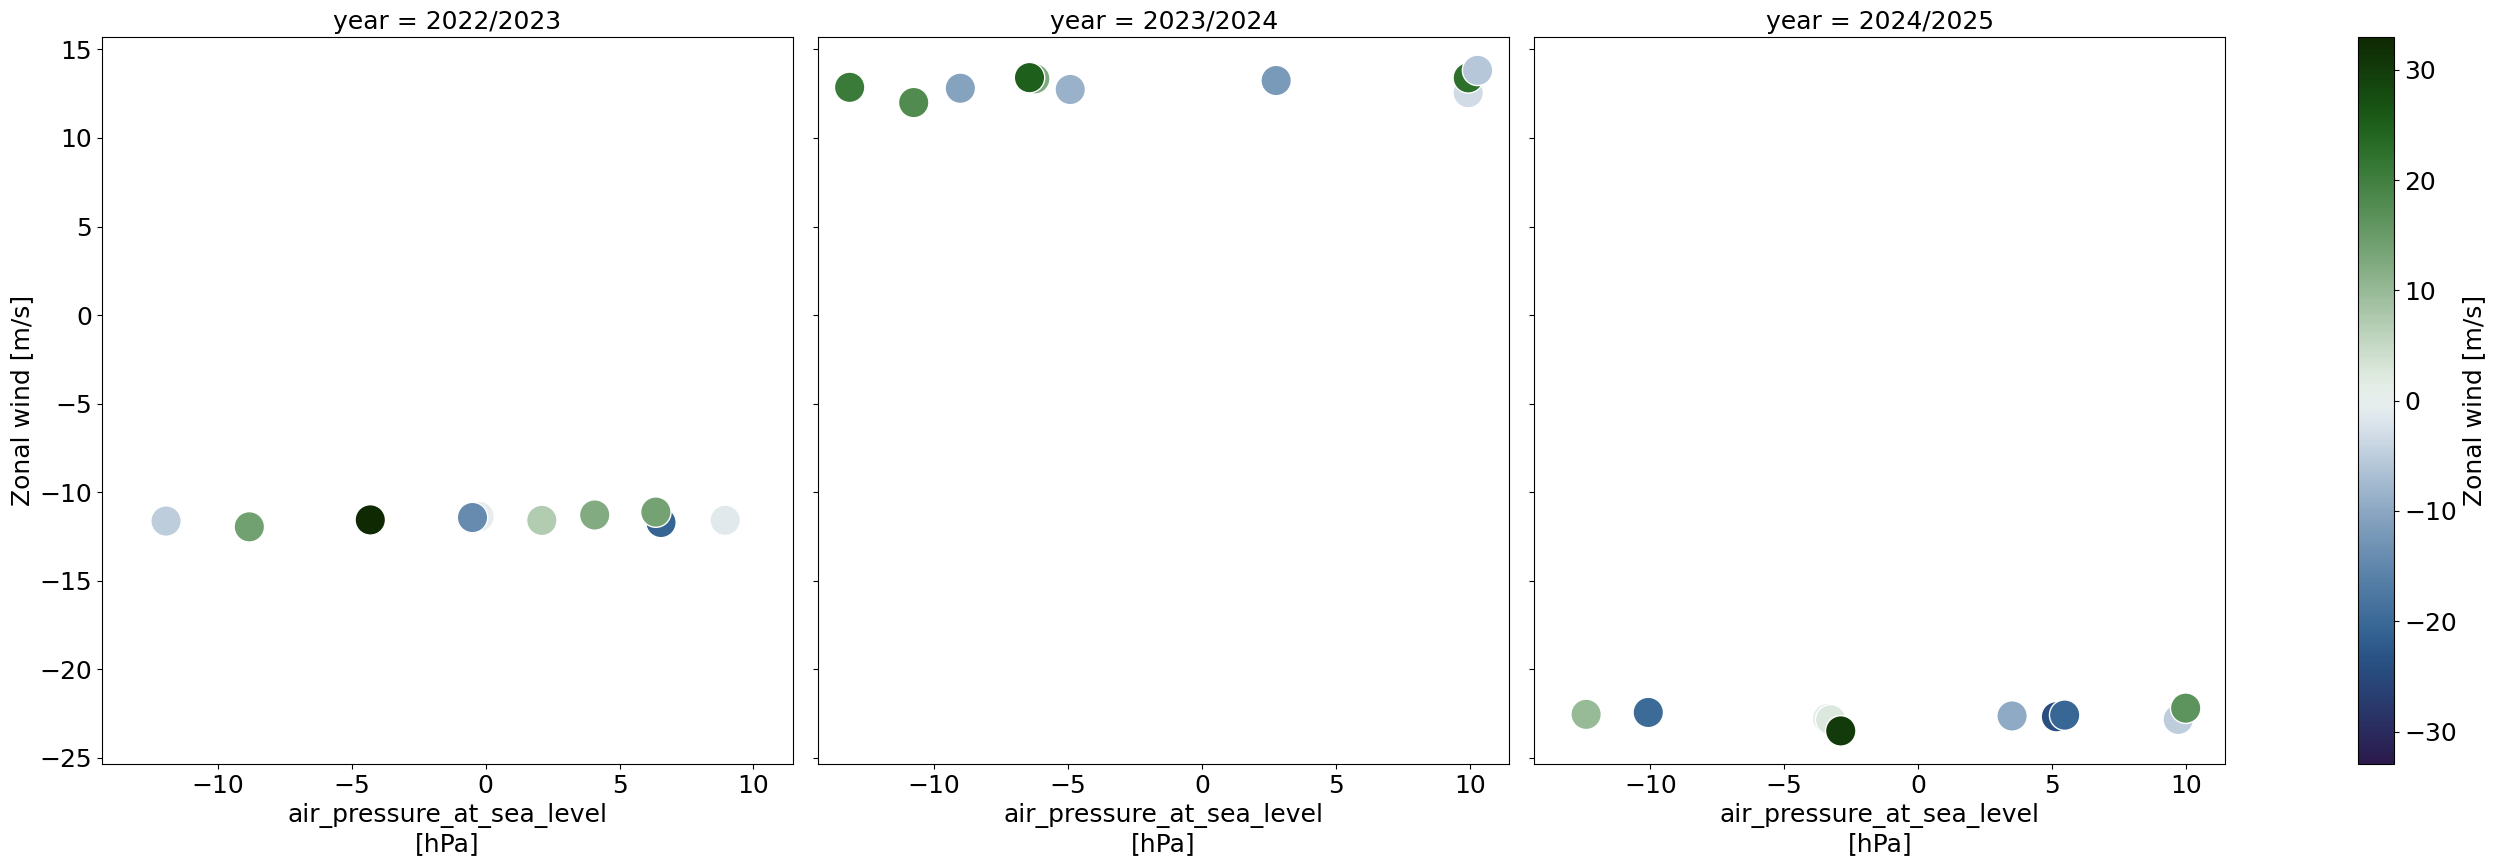

In [629]:
temp_all.plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', col = 'year', cmap = cmap, size = 9, **dict(s=480))

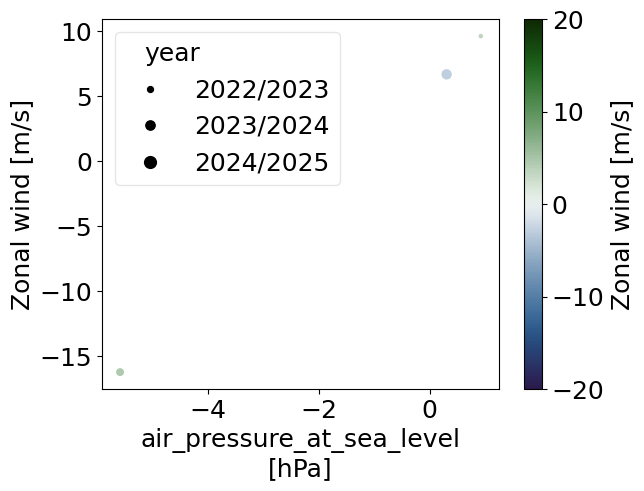

In [568]:
temp_all.median('ens').plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', markersize = 'year', cmap = cmap, vmax = 20, vmin = -20)

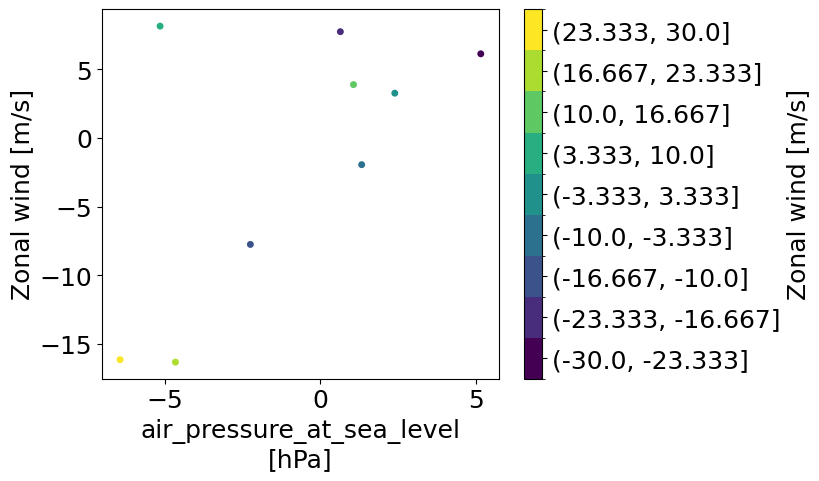

In [564]:
temp_all.groupby_bins("u6010", np.linspace(-30,30,10)).mean().plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010_bins')

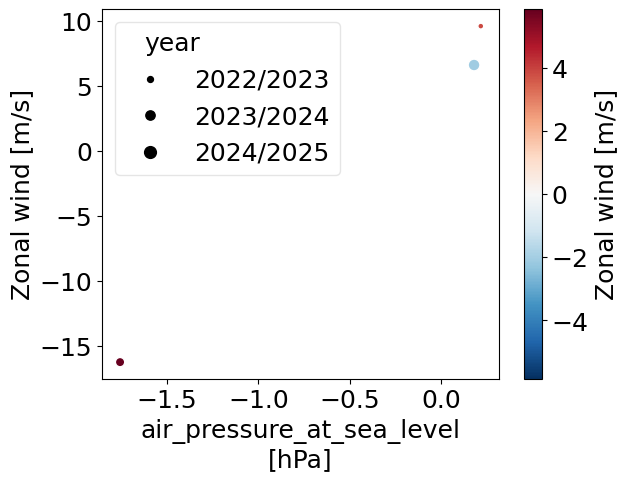

In [551]:
temp_all.mean('ens').plot.scatter(x = 'psl', y = 'u_m', hue = 'u6010', markersize = 'year')

In [680]:
soi_qbo = xr.merge([soi_w, qboi_w.squeeze().reset_coords(drop=True)])#, diff_pv.reset_coords(drop=True)])
soi_qbo

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 60, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
    month    (time) float64 480B nan nan nan nan nan ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    psl      (ens, time) float32 2kB nan nan nan nan ... 9.739 5.481 7.381 nan
    u_m      (ens, time) float32 2kB -21.92 -27.34 -30.37 ... -9.375 -6.437
Attributes:
    standard_name:     air_pressure_at_sea_level
    units:             hPa
    code:              151
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    cell_methods:      time: mean

In [681]:
soi_qbo

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 60, ens: 10)
Coordinates:
  * time     (time) datetime64[ns] 480B 2021-01-31 2021-02-28 ... 2025-12-31
  * ens      (ens) <U1 40B '0' '1' '2' '3' '4' '5' '6' '7' '8' '9'
    month    (time) float64 480B nan nan nan nan nan ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    psl      (ens, time) float32 2kB nan nan nan nan ... 9.739 5.481 7.381 nan
    u_m      (ens, time) float32 2kB -21.92 -27.34 -30.37 ... -9.375 -6.437
Attributes:
    standard_name:     air_pressure_at_sea_level
    units:             hPa
    code:              151
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48
    cell_methods:      time: mean

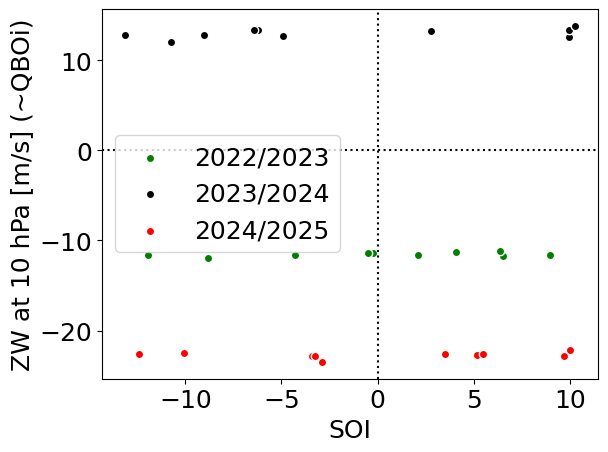

In [684]:
soi_qbo.sel(time = slice('2022-09','2022-11')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'g', label = '2022/2023')
soi_qbo.sel(time = slice('2023-09','2023-11')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'k', label = '2023/2024')
soi_qbo.sel(time = slice('2024-09','2024-11')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'r', label = '2024/2025')
plt.legend()
plt.ylabel('ZW at 10 hPa [m/s] (~QBOi)')
plt.xlabel('SOI')
plt.title('')
plt.axhline(c = 'k', ls='dotted')
plt.axvline(c = 'k', ls='dotted')

plt.savefig('QBO@10hPa_vs_SOI_SOCOLw-only.pdf',  bbox_inches='tight')

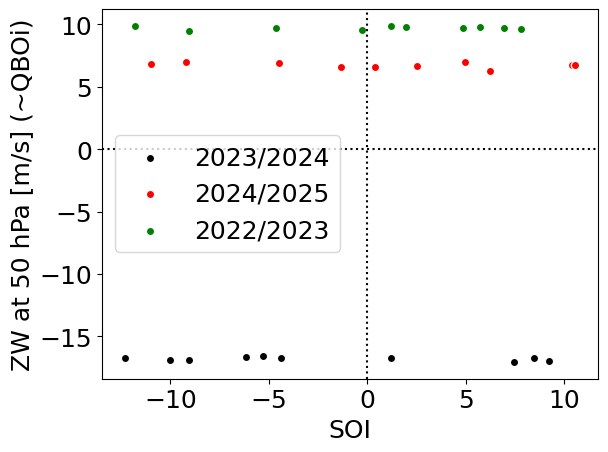

In [395]:
soi_qbo.sel(time = slice('2023-09','2023-12')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'k', label = '2023/2024')
soi_qbo.sel(time = slice('2024-09','2024-12')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'r', label = '2024/2025')
soi_qbo.sel(time = slice('2022-09','2022-12')).mean('time').plot.scatter(x = 'psl', y = 'u_m', c = 'g', label = '2022/2023')
plt.legend()
plt.ylabel('ZW at 50 hPa [m/s] (~QBOi)')
plt.xlabel('SOI')
plt.title('')
plt.axhline(c = 'k', ls='dotted')
plt.axvline(c = 'k', ls='dotted')

plt.savefig('QBO_vs_SOI_SOCOLw-only.pdf',  bbox_inches='tight')

([<matplotlib.axis.YTick at 0x7fc2f7f4a890>,
 [Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 0.1, '$\\mathdefault{10^{-1}}$')])

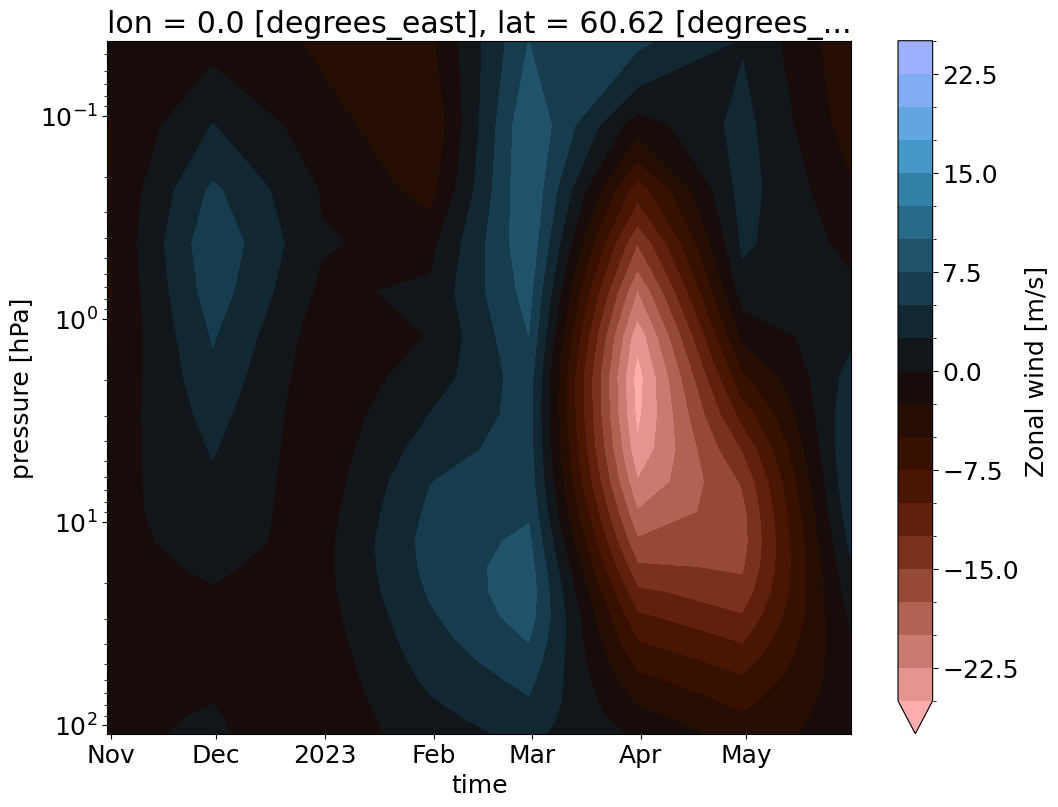

In [431]:
sel_var = 'u_m'
sel_dict = dict(lat = 60, method = 'nearest')

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().sel(time = slice('2022-10', '2023-05')).plot.contourf(x = 'time', levels = 21, yincrease = False, robust = True, cmap = 'berlin_r', size = 9)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc2742a6490>,
 [Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 0.1, '$\\mathdefault{10^{-1}}$')])

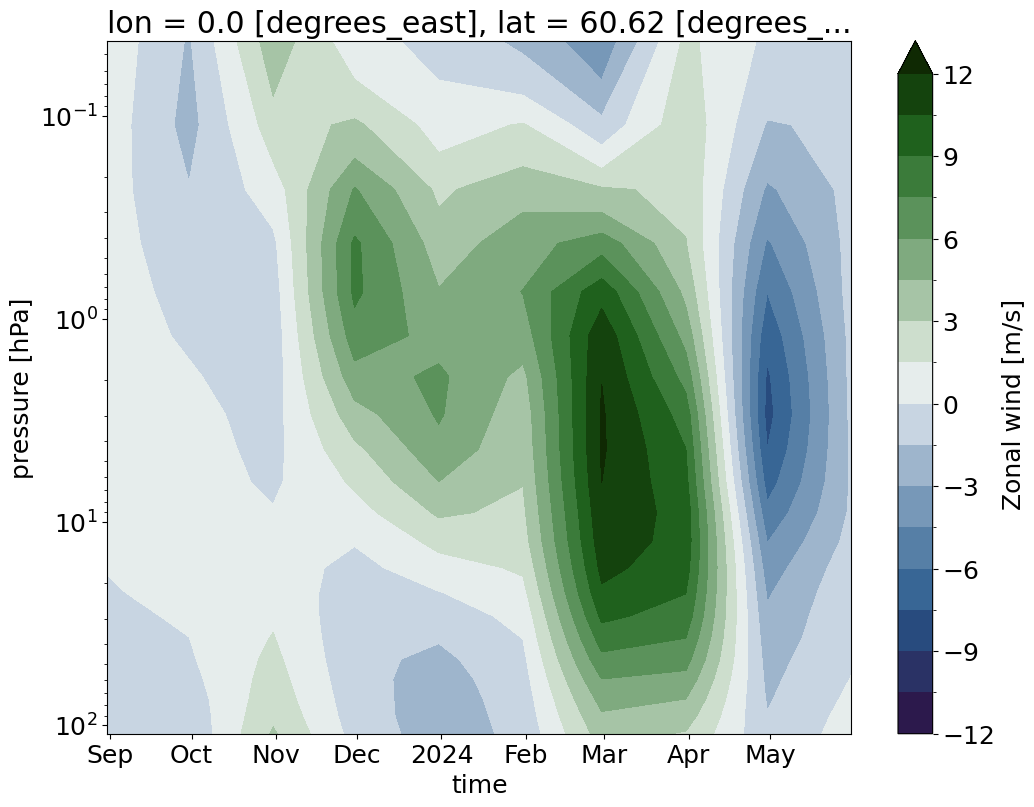

In [762]:
sel_var = 'u_m'
sel_dict = dict(lat = 60, method = 'nearest')

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().sel(time = slice('2023-08', '2024-05')).plot.contourf(x = 'time', levels = 21, yincrease = False, robust = True, cmap = cmap, size = 9)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc2400be010>,
 [Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 0.1, '$\\mathdefault{10^{-1}}$')])

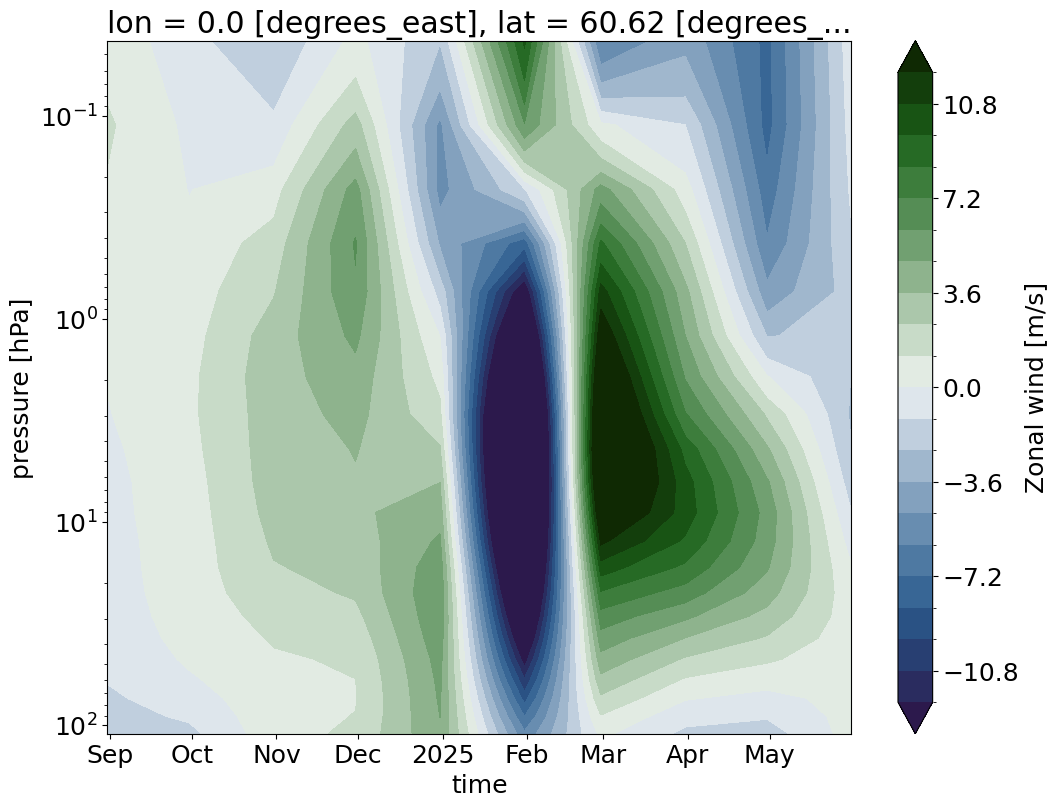

In [763]:
sel_var = 'u_m'
sel_dict = dict(lat = 60, method = 'nearest')

diff = (ds_w_chem[sel_var].sel(**sel_dict)- ds_wo_chem[sel_var].sel(**sel_dict)).mean(['ens']) 
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().sel(time = slice('2024-08', '2025-05')).plot.contourf(x = 'time', levels = 21, yincrease = False, vmax = 12, cmap = cmap, size = 9) # 'berlin_r'
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc28c44f050>,
 [Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 0.1, '$\\mathdefault{10^{-1}}$')])

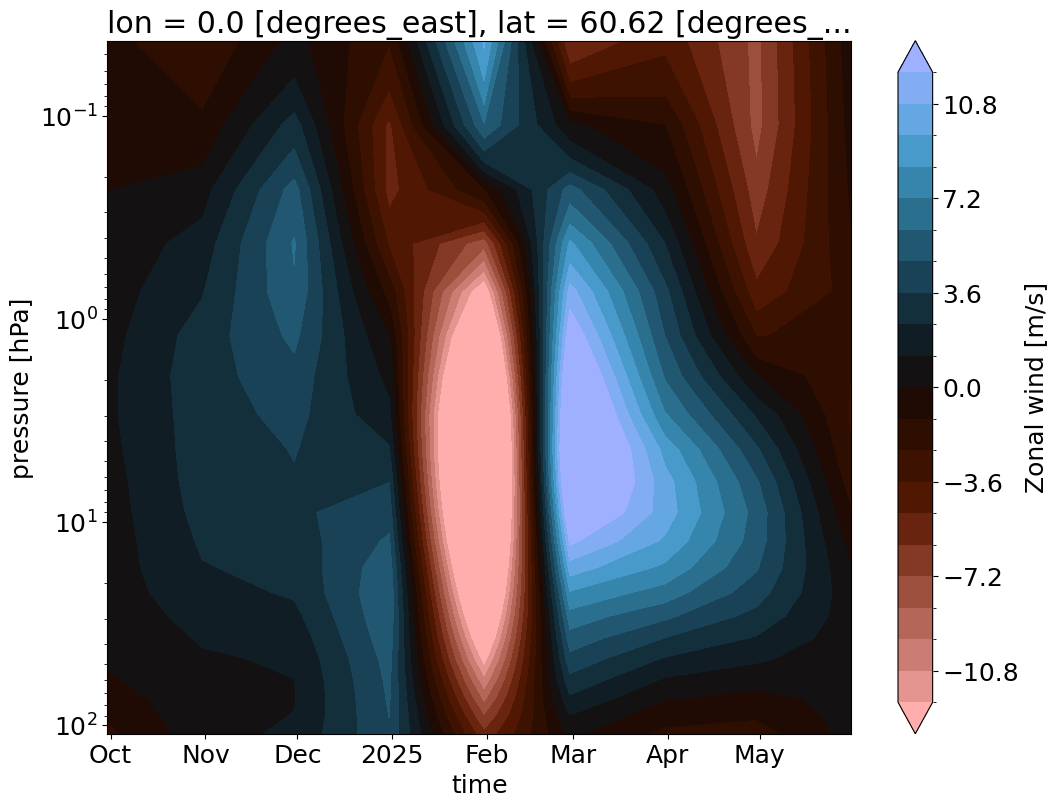

In [686]:
sel_var = 'u_m'
sel_dict = dict(lat = 60, method = 'nearest')

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().sel(time = slice('2024-09', '2025-05')).plot.contourf(x = 'time', levels = 21, yincrease = False, vmax = 12, cmap = 'berlin_r', size = 9)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc241336250>,
 [])

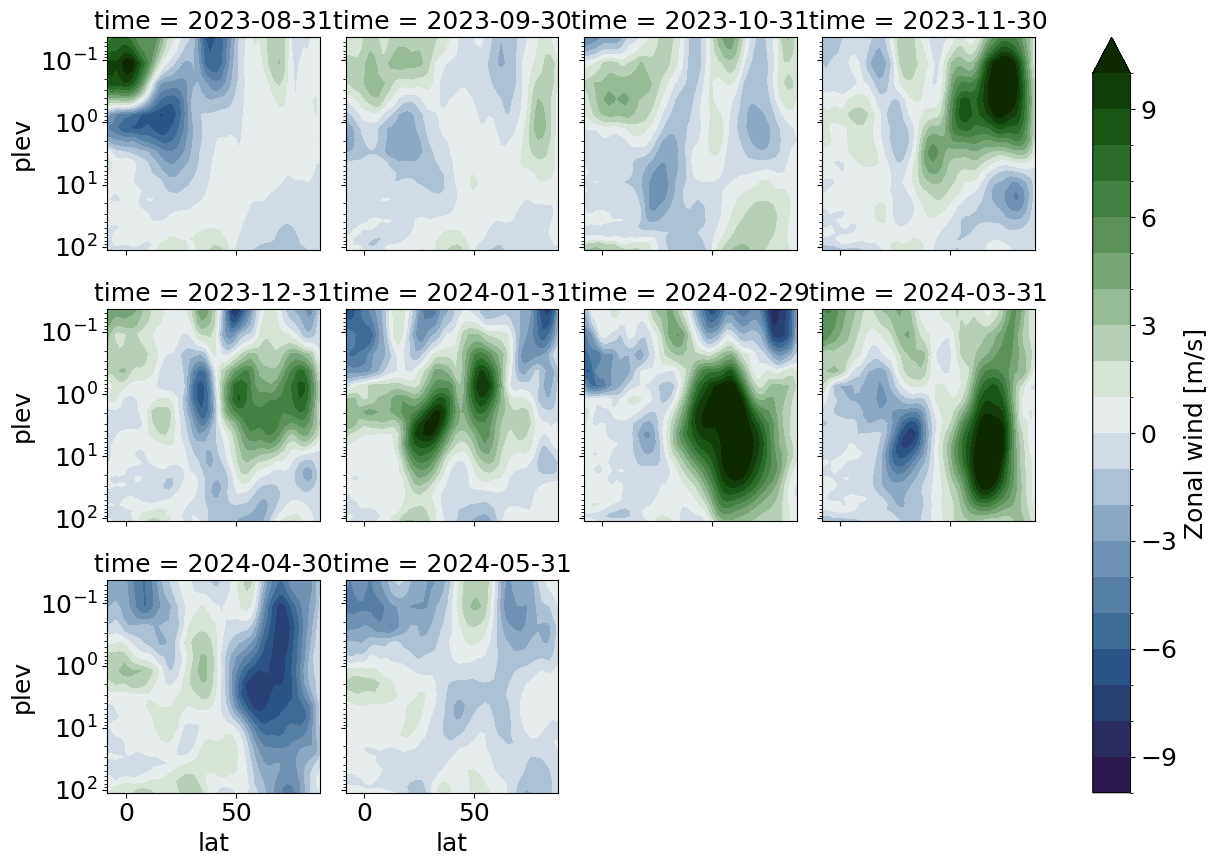

In [765]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-08', '2024-05'), lat = slice(None,-10))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = cmap)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc22bf2e910>,
 [])

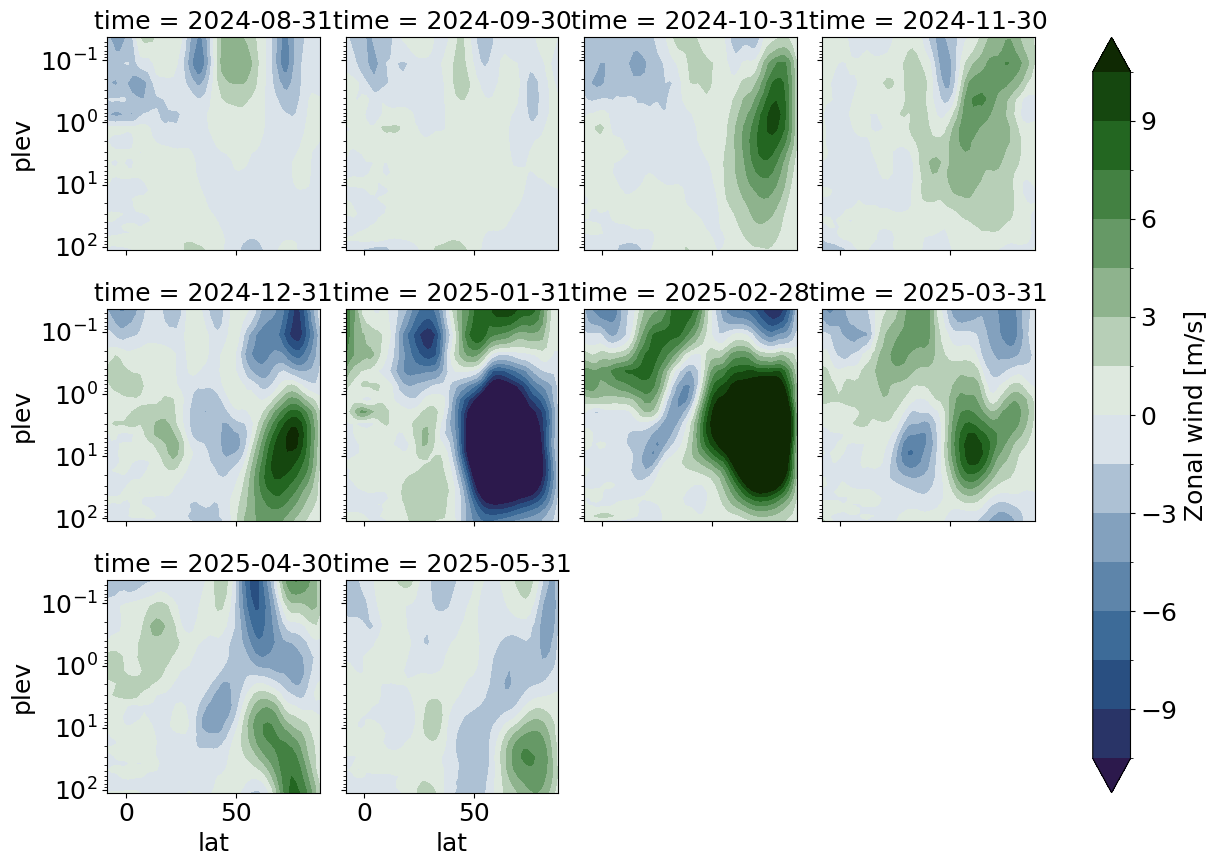

In [766]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2024-08', '2025-05'), lat = slice(None,-10))

diff = (ds_w_chem[sel_var].sel(**sel_dict).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = cmap)
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc30eee5490>,
 [])

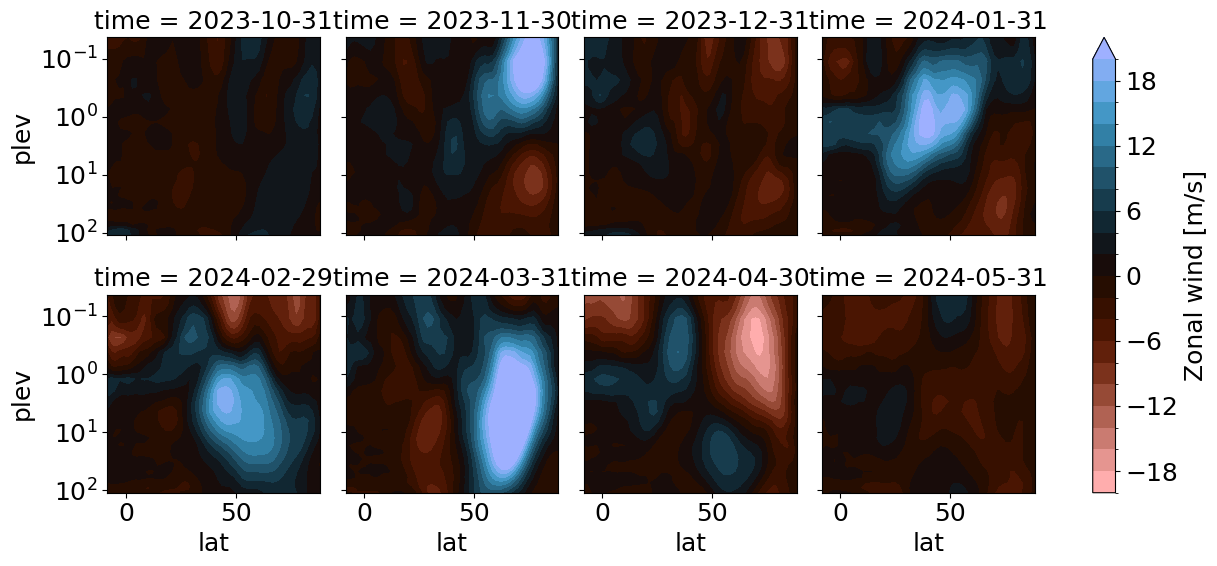

In [421]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = (ds_w_chem[sel_var].sel(**sel_dict).sel(ens = mask).mean(['ens']) - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc30ed29d10>,
 [])

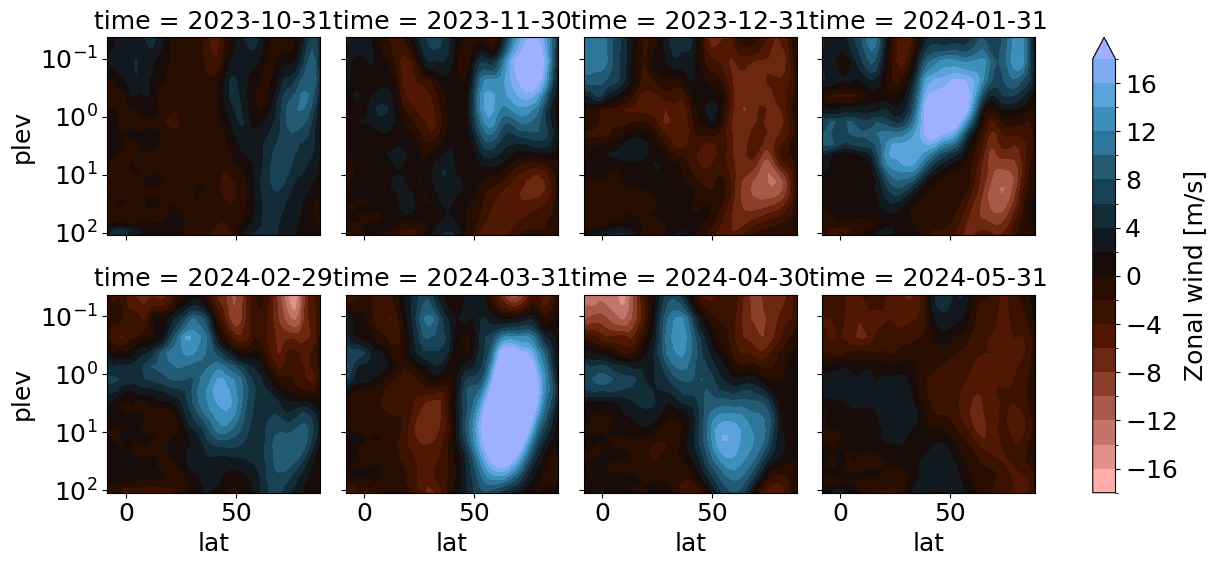

In [422]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = (ds_w_chem[sel_var].sel(**sel_dict).sel(ens = ['htt17', 'htt14']).mean('ens') - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc34701de50>,
 [])

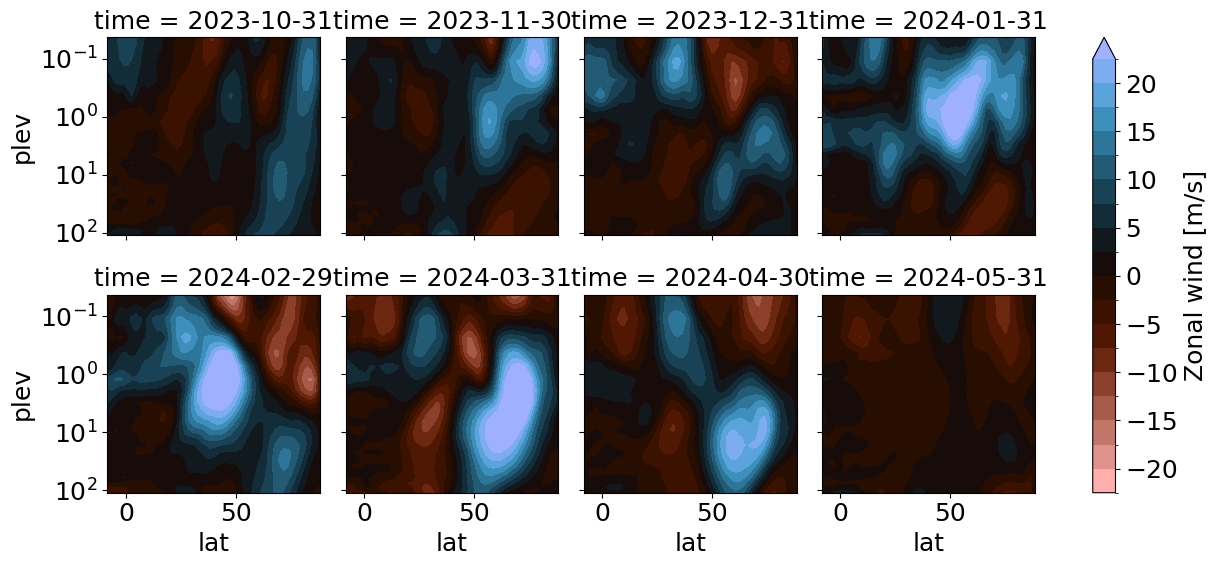

In [420]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = (ds_w_chem[sel_var].sel(**sel_dict).sel(ens = 'htt17') - ds_wo_chem[sel_var].sel(**sel_dict).mean(['ens']))
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = True, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc30c6af290>,
 [])

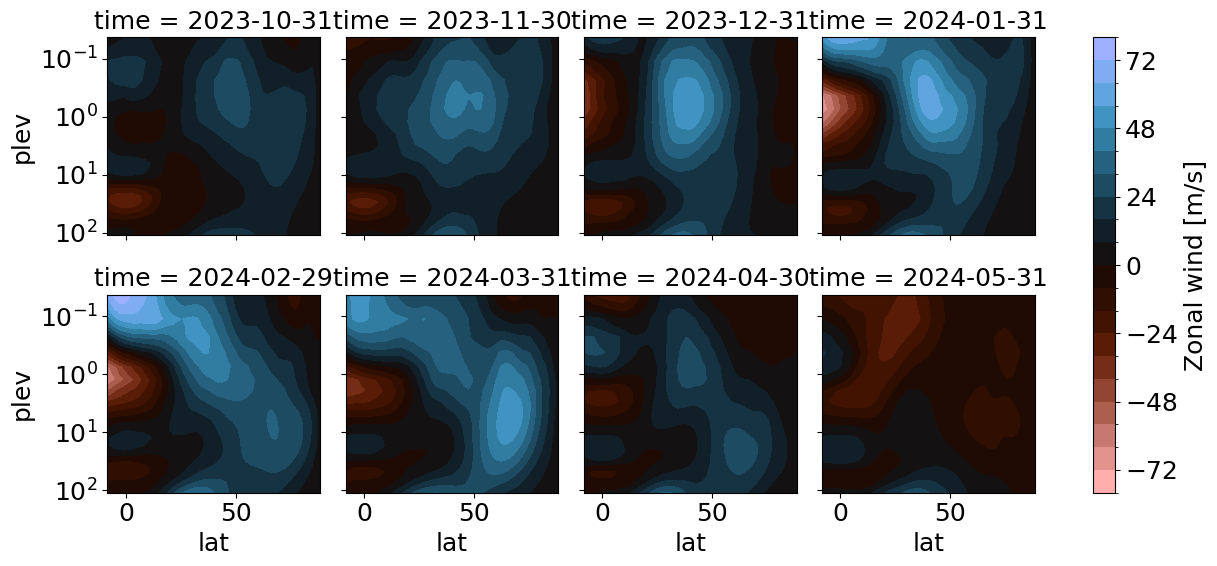

In [414]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = ds_w_chem[sel_var].sel(**sel_dict).sel(ens = ['htt17'])
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = False, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc307b76810>,
 [])

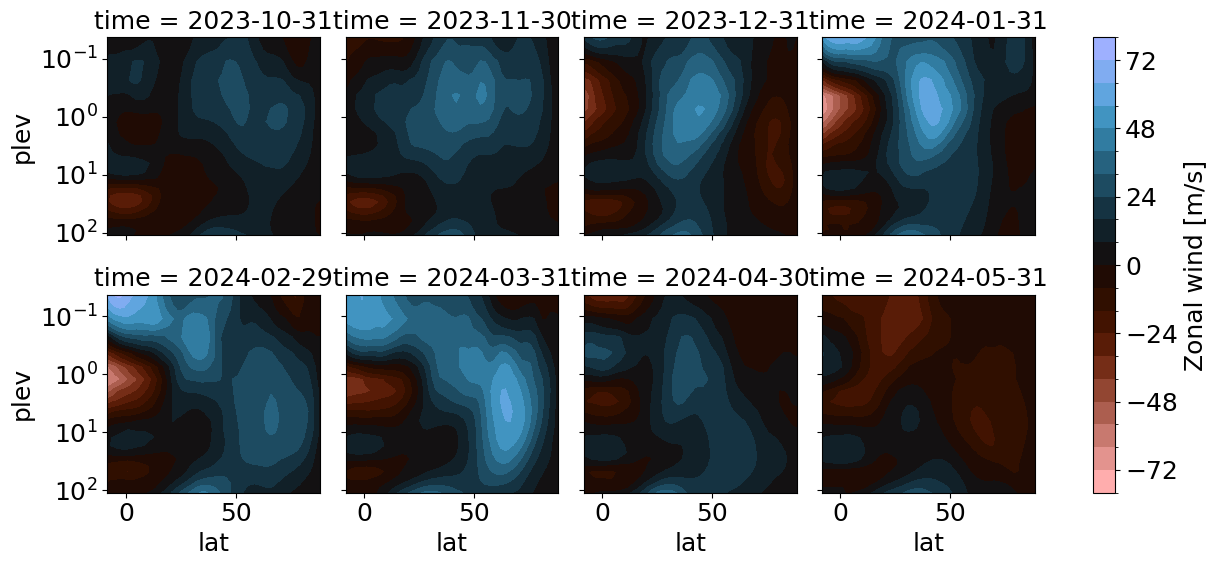

In [415]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = ds_w_chem[sel_var].sel(**sel_dict).sel(ens = ['htt14'])
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = False, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

([<matplotlib.axis.YTick at 0x7fc345968510>,
 [])

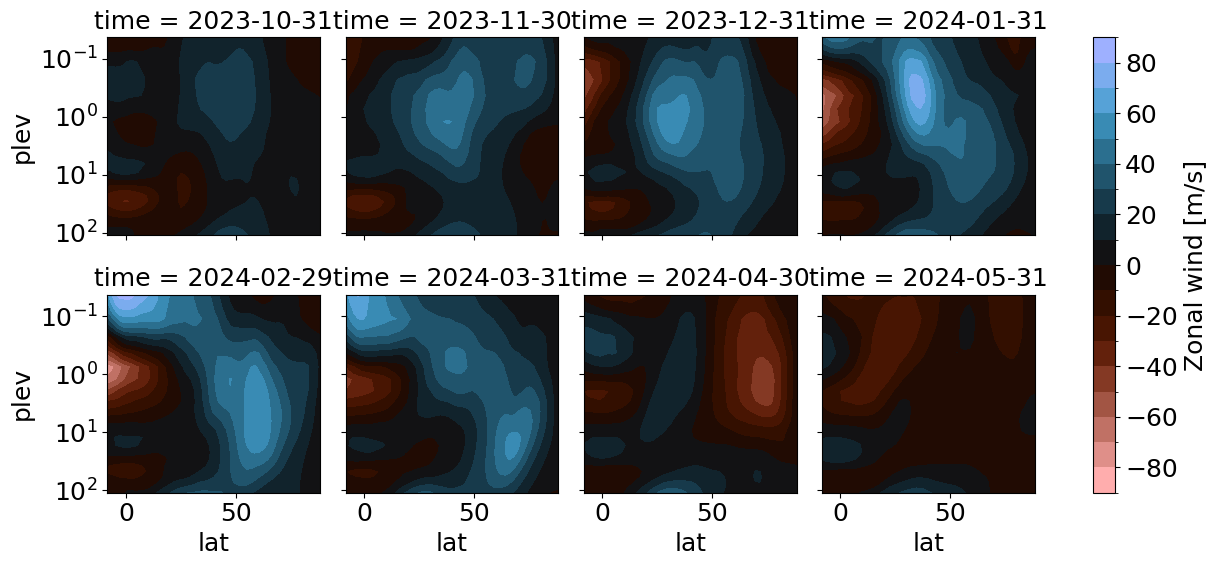

In [416]:
sel_var = 'u_m'
sel_dict = dict(time = slice('2023-10', '2024-05'), lat = slice(None,-10))
temp = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
mask = temp.where(temp > 5, drop = True).ens

diff = ds_w_chem[sel_var].sel(**sel_dict).sel(ens = ['htt15'])
diff.plev.attrs['units'] = 'hPa'
diff.squeeze().plot.contourf(col = 'time', levels = 21, yincrease = False, col_wrap = 4, robust = False, cmap = 'berlin_r')
plt.yscale('log')
plt.yticks([100,10,1,0.1])
#plt.title('polar uppwer stratosphere')

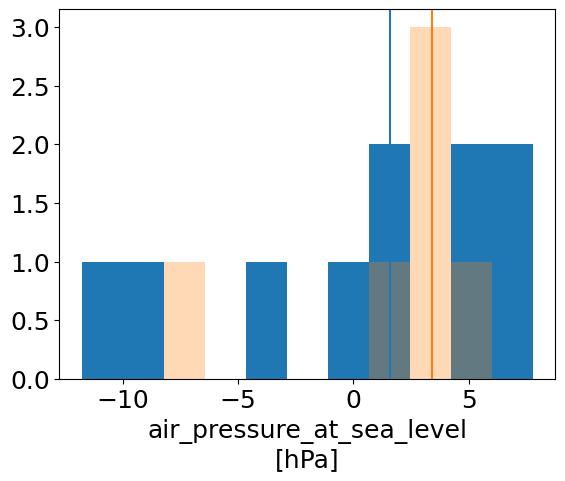

In [320]:
arr1 = soi_w.sel(time = slice('2022-09','2022-12')).mean('time')
bins = arr1.plot.hist(bins = 11)
temp = arr1.median()
plt.axvline(temp.values, color ='C0')
arr2 = soi_wo.sel(time = slice('2022-09','2022-12')).mean('time')
arr2.plot.hist(bins = bins[1], alpha = 0.3)
temp = arr2.median()
plt.axvline(temp.values, color ='C1')
#plt.axvline(ds_era['soi'].sel(time = slice('2023-09','2023-12')).mean().values, c = 'k')
#plt.axvline(ds_era['soi'].sel(time = slice('2024-09','2024-12')).mean().values, c = 'k', ls = 'dotted')

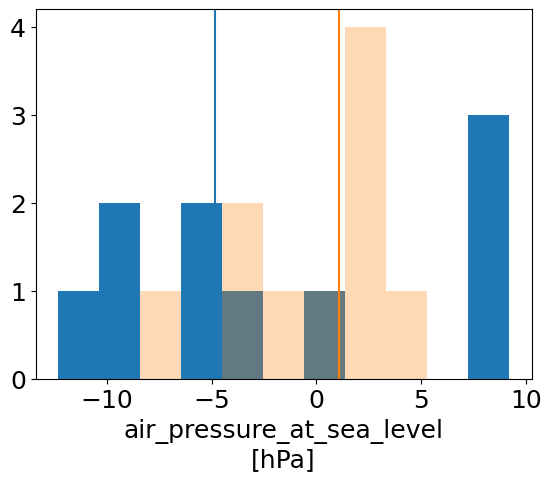

In [401]:
arr1 = soi_w.sel(time = slice('2023-09','2023-12')).mean('time')
bins = arr1.plot.hist(bins = 11)
temp = arr1.median()
plt.axvline(temp.values, color ='C0')
arr2 = soi_wo.sel(time = slice('2023-09','2023-12')).mean('time')
arr2.plot.hist(bins = bins[1], alpha = 0.3)
temp = arr2.median()
plt.axvline(temp.values, color ='C1')
#plt.axvline(ds_era['soi'].sel(time = slice('2023-09','2023-12')).mean().values, c = 'k')
#plt.axvline(ds_era['soi'].sel(time = slice('2024-09','2024-12')).mean().values, c = 'k', ls = 'dotted')

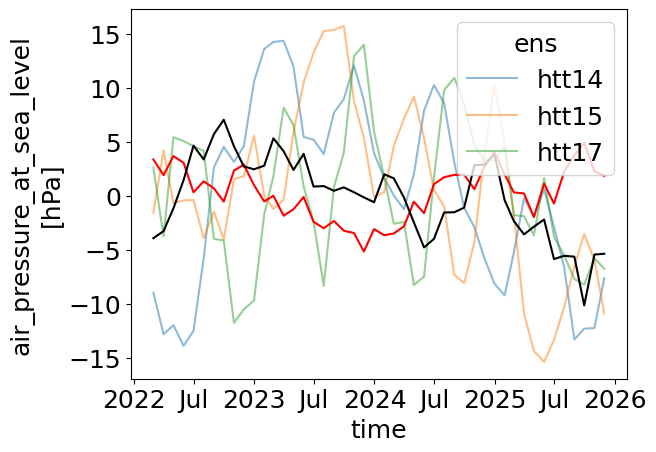

In [405]:
mask = arr1.where(arr1 > 5, drop = True).ens
soi_w.sel(ens = mask).plot(hue = 'ens', alpha = 0.5)
#soi_w.sel(ens = mask).mean('ens').plot(c = 'g')
soi_w.median('ens').plot(c = 'r')
soi_wo.median('ens').plot(c = 'k')

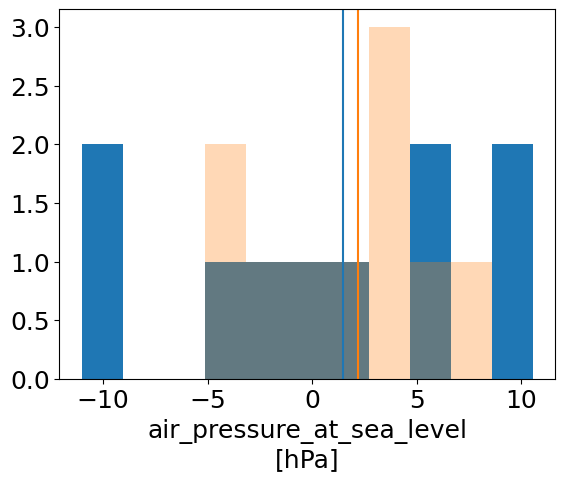

In [314]:
arr1 = soi_w.sel(time = slice('2024-09','2024-12')).mean('time')
bins = arr1.plot.hist(bins = 11)
temp = arr1.median()
plt.axvline(temp.values, color ='C0')
arr2 = soi_wo.sel(time = slice('2024-09','2024-12')).mean('time')
arr2.plot.hist(bins = bins[1], alpha = 0.3)
temp = arr2.median()
plt.axvline(temp.values, color ='C1')
#plt.axvline(ds_era['soi'].sel(time = slice('2023-09','2023-12')).mean().values, c = 'k')
#plt.axvline(ds_era['soi'].sel(time = slice('2024-09','2024-12')).mean().values, c = 'k', ls = 'dotted')

# from Bruno

In [193]:
ds_w = anomalize(xr.open_dataset('socol_SOI_pert.nc'))
ds_wo = anomalize(xr.open_dataset('socol_SOI_ctrl.nc'))
ds_era = anomalize(xr.open_dataset('soi_era5.nc'))

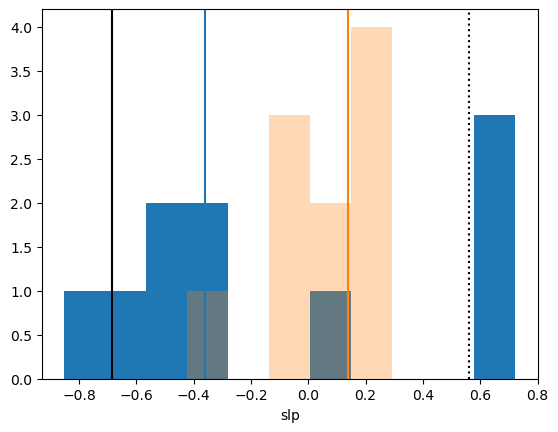

In [50]:
arr1 = ds_w['slp'].sel(time = slice('2023-09','2023-12')).mean('time')
bins = arr1.plot.hist(bins = 11)
temp = arr1.median()
plt.axvline(temp.values, color ='C0')
arr2 = ds_wo['slp'].sel(time = slice('2023-09','2023-12')).mean('time')
arr2.plot.hist(bins = bins[1], alpha = 0.3)
temp = arr2.median()
plt.axvline(temp.values, color ='C1')
plt.axvline(ds_era['soi'].sel(time = slice('2023-09','2023-12')).mean().values, c = 'k')
plt.axvline(ds_era['soi'].sel(time = slice('2024-09','2024-12')).mean().values, c = 'k', ls = 'dotted')

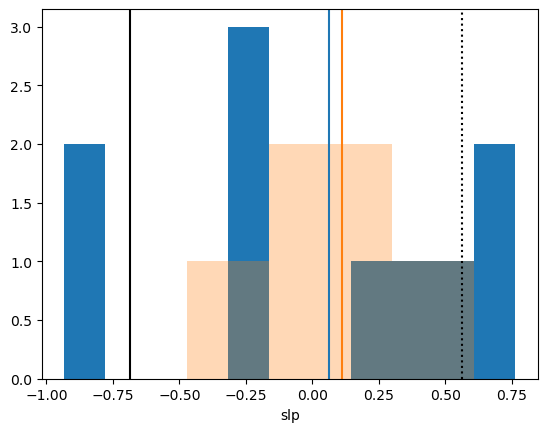

In [52]:
arr1 = ds_w['slp'].sel(time = slice('2024-09','2024-12')).mean('time')
bins = arr1.plot.hist(bins = 11)
temp = arr1.median()
plt.axvline(temp.values, color ='C0')
arr2 = ds_wo['slp'].sel(time = slice('2024-09','2024-12')).mean('time')
arr2.plot.hist(bins = bins[1], alpha = 0.3)
temp = arr2.median()
plt.axvline(temp.values, color ='C1')
plt.axvline(ds_era['soi'].sel(time = slice('2023-09','2023-12')).mean().values, c = 'k')
plt.axvline(ds_era['soi'].sel(time = slice('2024-09','2024-12')).mean().values, c = 'k', ls = 'dotted')

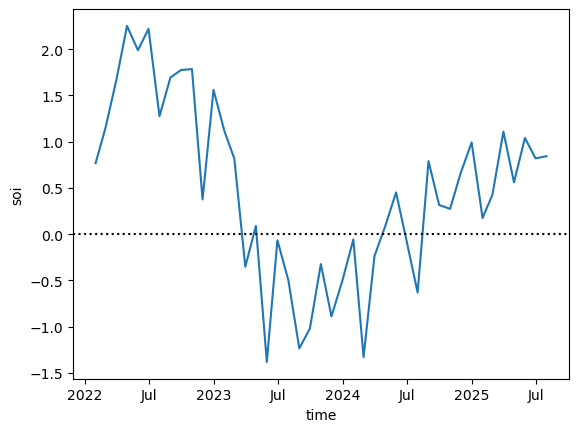

In [53]:
ds_era['soi'].sel(time = slice('2022',None)).plot()
plt.axhline(0, c = 'k', ls = 'dotted')

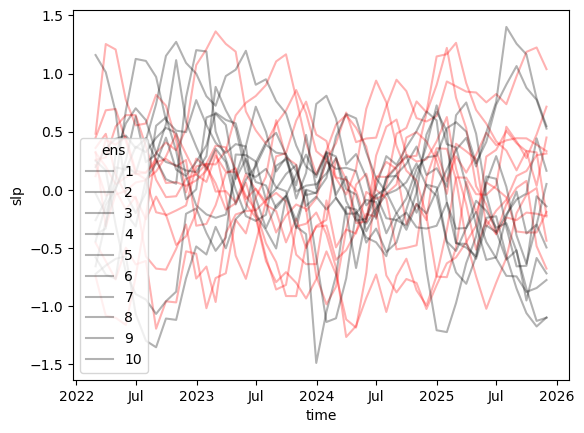

In [59]:
ds_w['slp'][:,12:].rolling(time = 3, center = True).mean().plot(c = 'r', hue = 'ens', alpha = 0.3)
ds_wo['slp'][:,12:].rolling(time = 3, center = True).mean().plot(c = 'k', hue = 'ens',alpha = 0.3)

#ds_wo['slp'].plot(hue = 'ens', c = 'k', alpha = 0.3)

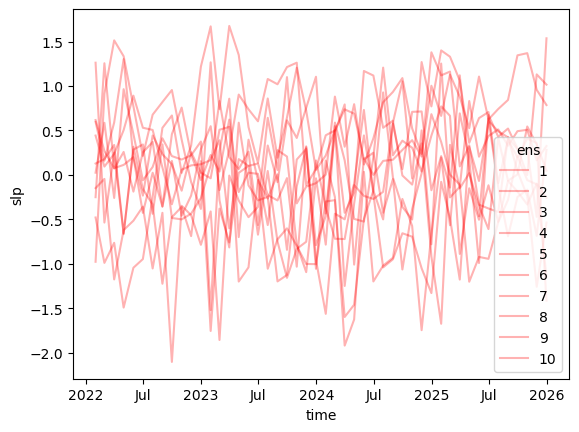

In [22]:
ds_w['slp'][:,12:].plot(hue = 'ens', c = 'r', alpha = 0.3)
#ds_wo['slp'].plot(hue = 'ens', c = 'k', alpha = 0.3)

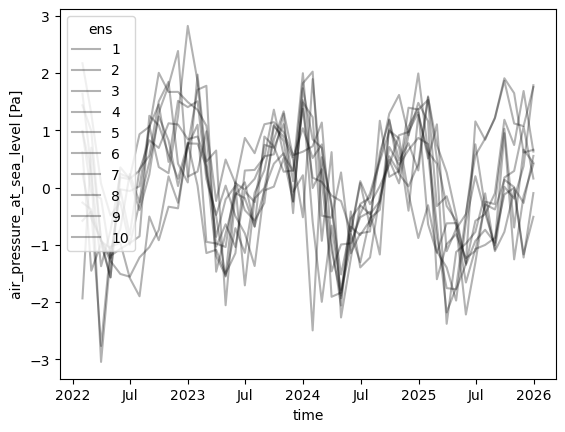

In [19]:
ds_wo['slp'][:,12:].plot(hue = 'ens', c = 'k', alpha = 0.3)

In [ ]:
ds